## **Introduction**
The UK Police dataset provides open access to detailed records of reported crimes, stop and search activities, and related outcomes across England, Wales, and Northern Ireland.  

In this project, we focus on **a five-month period from January 2025 to May 2025**, analysing three linked datasets to uncover patterns in crime reporting, outcomes of investigations, and stop-and-search activity.  

By cleaning and unifying the data, we build a foundation for exploratory analysis that can highlight temporal and geographic trends and support transparency and accountability in policing.


## **Data Summary**
The data was sourced from the [UK Police data archive](https://data.police.uk/data/archive/) and restricted to **January–May 2025**.  

- **Outcomes data (`df1`)**: ~1.87M rows, 10 columns.  
- **Stop and Search data (`df2`)**: ~159k rows, 14 columns.  
- **Street-level crimes (`df3`)**: ~2.21M rows, 11 columns.  

Key preprocessing steps:
- Unified missing values as `Unknown` or `NaN`.  
- Converted dates to `datetime64`.  
- IDs stored as strings.  
- Geolocation stored as floats.  
- Outcomes consistently under column `outcome`.  


## **Questions to Explore**

1. How many crimes were recorded between January and May 2025?

2. Which crime types were most common?

3. What outcomes (e.g., prosecution, no further action) appear most often?

4. How many stop & search events were recorded, and what were their outcomes?

5. Do stop & search outcomes differ by age, gender, or ethnicity?

#

## **Project Objectives**

1. Clean and prepare the data

- Standardise formats, fix missing values, and ensure consistency across the three datasets.

2. Summarise crime patterns

- Look at overall levels of reported crime, stop & search activity, and outcomes during Jan–May 2025.

3. Explore outcomes

- Check how different crime types are resolved (e.g., prosecutions, no further action, local resolutions).

4. Check stop & search records

- Review outcomes of stop & search and basic demographic patterns (age, gender, ethnicity).

5. Highlight data gaps

- Identify where information is missing or marked as “Unknown” to understand data quality.

## **Imports**

In [ ]:
!pip install folium
# Core
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency


# Mapping
import folium
from folium.plugins import MarkerCluster, HeatMap
from IPython.display import IFrame

# Utilities
import re
import glob
import os

## **Data Dictionary**

1. df1 – Outcomes

| Column         | Description                                                       |
| -------------- | ----------------------------------------------------------------- |
| `crime_id`     | Unique identifier for each recorded crime.                        |
| `month`        | Month when crime was recorded (datetime).                         |
| `reported_by`  | Police force reporting the crime.                                 |
| `falls_within` | Police force jurisdiction where the crime occurred.               |
| `longitude`    | Longitude coordinate of crime location.                           |
| `latitude`     | Latitude coordinate of crime location.                            |
| `location`     | Approximate street or area where crime occurred.                  |
| `lsoa_code`    | LSOA (Lower Layer Super Output Area) code – small area geography. |
| `lsoa_name`    | LSOA name (local authority with code).                            |
| `outcome`      | Recorded outcome of the crime (e.g., Arrest, No further action).  |

2. df2 – Stop & Search

| Column                                     | Description                                               |
| ------------------------------------------ | --------------------------------------------------------- |
| `type`                                     | Type of stop (always stop-and-search).                    |
| `date`                                     | Date of stop (datetime).                                  |
| `part_of_a_policing_operation`             | Whether the stop was part of an operation (bool).         |
| `latitude`                                 | Latitude of stop location.                                |
| `longitude`                                | Longitude of stop location.                               |
| `gender`                                   | Gender of the person stopped.                             |
| `age_range`                                | Age group of the person stopped (e.g., 18–24, over 34).   |
| `self-defined_ethnicity`                   | Ethnicity as self-defined by the individual.              |
| `officer-defined_ethnicity`                | Ethnicity as perceived by the officer.                    |
| `legislation`                              | Legal power under which the search was conducted.         |
| `object_of_search`                         | Object being searched for (e.g., drugs, stolen property). |
| `outcome`                                  | Result of the search (e.g., Arrest, No further action).   |
| `outcome_linked_to_object_of_search`       | Whether the outcome was related to the object searched.   |
| `removal_of_more_than_just_outer_clothing` | Whether clothing removal beyond outer layers occurred.    |
| `day_of_week`                              | Day of the week derived from date.                        |


3. df3 – Street Crimes

| Column         | Description                                           |
| -------------- | ----------------------------------------------------- |
| `crime_id`     | Unique identifier for the crime.                      |
| `month`        | Month when the crime was recorded (datetime).         |
| `reported_by`  | Police force reporting the crime.                     |
| `falls_within` | Police force jurisdiction.                            |
| `longitude`    | Longitude coordinate of crime location.               |
| `latitude`     | Latitude coordinate of crime location.                |
| `location`     | Approximate street or area.                           |
| `lsoa_code`    | LSOA area code.                                       |
| `lsoa_name`    | LSOA area name.                                       |
| `outcome`      | Crime outcome if recorded.                            |
| `crime_type`   | Category of the crime (e.g., Violence, Theft, Drugs). |



In [2]:


# Base folder
base_path = r"C:\Users\Sarunas\Documents\Police Data"

# Categories to merge separately
categories = {
    "outcomes": "*-outcomes.csv",
    "stop_and_search": "*-stop-and-search.csv",
    "street": "*-street.csv"
}

# Months you want to merge (last 5 months)
months = ["2025-01", "2025-02", "2025-03", "2025-04", "2025-05"]

for category, pattern in categories.items():
    all_files = []
    for month in months:
        # Search all forces for this category in that month
        month_files = glob.glob(os.path.join(base_path, month, pattern))
        all_files.extend(month_files)

    # Read and combine
    df_list = []
    for file in all_files:
        df = pd.read_csv(file, low_memory=False)
        df_list.append(df)

    combined_df = pd.concat(df_list, ignore_index=True)

    # Save to CSV
    output_file = f"{category}_5months.csv"
    combined_df.to_csv(output_file, index=False)

    print(f"✅ {category}: {len(combined_df)} rows saved to {output_file}")


✅ outcomes: 1952705 rows saved to outcomes_5months.csv
✅ stop_and_search: 170890 rows saved to stop_and_search_5months.csv
✅ street: 2327849 rows saved to street_5months.csv


## **Loading and Inspecting the Data**

In [3]:
df1 = pd.read_csv('outcomes_5months.csv')

In [4]:
df1.head()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Outcome type
0,9a6df6be8891d0d563b6e3b8a805f221b134b8eda665ea...,2025-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.704043,51.387847,On or near Downside Road,E01014854,North Somerset 013D,Unable to prosecute suspect
1,0d99bdcd6594184d351f0513d71635162e9e4a756f1a79...,2025-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Further investigation is not in the public int...
2,ae2635027b0484e1ef028b833ba5a795a3f33104ac9c82...,2025-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.576637,51.459290,On or near Harleston Street,E01033358,Bristol 054D,Formal action is not in the public interest
3,d4250554f997530722b58740c8679665f3327de2e5b601...,2025-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Unable to prosecute suspect
4,5fcb9a243ac6f29f7ef5bcf6d316d8936897ea315220ec...,2025-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Unable to prosecute suspect


In [5]:
df1.tail()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Outcome type
1952700,626e22babc731a732583a55a8b7cd3e3bf35fb468fec11...,2025-05,Wiltshire Police,Wiltshire Police,-2.137578,51.372429,On or near Watson's Court,E01032068,Wiltshire 022D,Investigation complete; no suspect identified
1952701,3147bcee9f8984a56eca43b272ff501f69d987960428c4...,2025-05,Wiltshire Police,Wiltshire Police,-1.781431,51.558845,On or near Regent Circus,E01032714,Swindon 019E,Investigation complete; no suspect identified
1952702,d95e10fc53ae2a66eb15a8355e19e684f9689e2d430d2c...,2025-05,Wiltshire Police,Wiltshire Police,-1.977236,51.083878,On or near Spracklands,E01032004,Wiltshire 054B,Investigation complete; no suspect identified
1952703,deb166f2809eed9b8d4ec3995e748ef56885755eabfb06...,2025-05,Wiltshire Police,Wiltshire Police,-1.766340,51.169476,On or near Jaggard View,E01031978,Wiltshire 048E,Investigation complete; no suspect identified
1952704,b69e992b234daa9feaf4a33e636ca96b2eafb28bac24a5...,2025-05,Wiltshire Police,Wiltshire Police,-1.769992,51.561863,On or near Dudmore Road,E01015574,Swindon 017C,Formal action is not in the public interest


In [6]:
df1.isnull().sum()

Crime ID            0
Month               0
Reported by         0
Falls within        0
Longitude       28125
Latitude        28125
Location            0
LSOA code       28127
LSOA name       28127
Outcome type        0
dtype: int64

In [7]:
df1.duplicated().sum()

82253

In [8]:
df1.shape

(1952705, 10)

In [9]:
df2 = pd.read_csv('stop_and_search_5months.csv')

In [10]:
df2.head()

,Type,Date,Part of a policing operation,Policing operation,Latitude,Longitude,Gender,Age range,Self-defined ethnicity,Officer-defined ethnicity,Legislation,Object of search,Outcome,Outcome linked to object of search,Removal of more than just outer clothing
0,Person and Vehicle search,2025-01-01T01:49:14+00:00,NaN,NaN,51.491668,-2.492035,Male,18-24,Black/African/Caribbean/Black British - Any ot...,Black,Misuse of Drugs Act 1971 (section 23),Controlled drugs,Community resolution,True,False
1,Person and Vehicle search,2025-01-01T01:49:14+00:00,NaN,NaN,51.491668,-2.492035,Male,18-24,Black/African/Caribbean/Black British - Any ot...,Black,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,NaN,False
2,Person search,2025-01-01T02:09:24+00:00,NaN,NaN,NaN,NaN,Male,25-34,Black/African/Caribbean/Black British - African,Black,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,NaN,False
3,Person search,2025-01-01T02:09:24+00:00,NaN,NaN,NaN,NaN,Female,18-24,Other ethnic group - Not stated,Black,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,NaN,False
4,Person search,2025-01-01T02:09:24+00:00,NaN,NaN,NaN,NaN,Male,25-34,Black/African/Caribbean/Black British - African,Black,Misuse of Drugs Act 1971 (section 23),Controlled drugs,Arrest,True,False


In [11]:
df2.tail()

,Type,Date,Part of a policing operation,Policing operation,Latitude,Longitude,Gender,Age range,Self-defined ethnicity,Officer-defined ethnicity,Legislation,Object of search,Outcome,Outcome linked to object of search,Removal of more than just outer clothing
170885,Person search,2025-05-31T20:40:00+00:00,False,NaN,53.723700,-1.349975,Male,10-17,Other ethnic group - Not stated,Black,Police and Criminal Evidence Act 1984 (section 1),Offensive weapons,A no further action disposal,True,False
170886,Person search,2025-05-31T21:45:00+00:00,False,NaN,53.792204,-1.752853,Male,18-24,NaN,Asian,Misuse of Drugs Act 1971 (section 23),Controlled drugs,Summons / charged by post,False,False
170887,Person and Vehicle search,2025-05-31T21:50:00+00:00,False,NaN,53.594755,-1.317975,Male,over 34,White - English/Welsh/Scottish/Northern Irish/...,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,Arrest,True,True
170888,Person search,2025-05-31T22:00:00+00:00,False,NaN,53.801903,-1.581361,Male,over 34,NaN,Asian,Misuse of Drugs Act 1971 (section 23),Controlled drugs,Community resolution,True,False
170889,Person search,2025-05-31T22:23:00+00:00,False,NaN,53.796033,-1.541964,Male,10-17,NaN,NaN,Police and Criminal Evidence Act 1984 (section 1),Stolen goods,A no further action disposal,True,False


In [12]:
df2.isnull().sum()

Type                                             0
Date                                             0
Part of a policing operation                 89522
Policing operation                          170890
Latitude                                     19718
Longitude                                    19718
Gender                                       11240
Age range                                    21054
Self-defined ethnicity                       13334
Officer-defined ethnicity                    13316
Legislation                                   6145
Object of search                             18016
Outcome                                       7330
Outcome linked to object of search           67421
Removal of more than just outer clothing     31535
dtype: int64

In [13]:
df2.duplicated().sum()

11906

In [14]:
df2.shape

(170890, 15)

In [15]:
df3 = pd.read_csv('street_5months.csv')

In [16]:
df3.head()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,5b3b243f3ae69b761588f65caefe62454587b15576ed55...,2025-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-1.084621,53.251666,On or near Limetree Avenue,E01033769,Bassetlaw 014F,Violence and sexual offences,Action to be taken by another organisation,NaN
1,1673f50aa688f77cc735d07f47a4f8fcff38d5ebcb70ed...,2025-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.511824,51.411782,On or near Westfield Close,E01014399,Bath and North East Somerset 001A,Criminal damage and arson,Under investigation,NaN
2,cf50d7824b02ca548125204807e34491d14de60b1812e7...,2025-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.508867,51.416147,On or near St Francis Road,E01014399,Bath and North East Somerset 001A,Violence and sexual offences,Local resolution,NaN
3,63e97874e46f7c886d2d9444741fa4651dac32af835e80...,2025-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.508867,51.416147,On or near St Francis Road,E01014399,Bath and North East Somerset 001A,Violence and sexual offences,Unable to prosecute suspect,NaN
4,7d93e2987187429aee7de3cc7d1042f7fe47086821296f...,2025-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.508867,51.416147,On or near St Francis Road,E01014399,Bath and North East Somerset 001A,Violence and sexual offences,Unable to prosecute suspect,NaN


In [17]:
df3.tail()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
2327844,c73a19e8066d8b25412ad81d00f9b54fae91ef30093f91...,2025-05,Wiltshire Police,Wiltshire Police,-1.661154,51.234168,On or near Supermarket,E01034558,Wiltshire 066E,Shoplifting,Under investigation,NaN
2327845,e6912d9619a46e5bd3c497df787c1fd33e8ef2e62d4a49...,2025-05,Wiltshire Police,Wiltshire Police,-1.660471,51.225777,On or near Ramnuggur Road,E01034558,Wiltshire 066E,Violence and sexual offences,Under investigation,NaN
2327846,21f16dedc869d33913f9d004a3e95913e5d8fa2e6b5a5f...,2025-05,Wiltshire Police,Wiltshire Police,-1.661154,51.234168,On or near Supermarket,E01034558,Wiltshire 066E,Violence and sexual offences,Under investigation,NaN
2327847,0ac70d59536954f60110fb47d338d40d486314af217a8b...,2025-05,Wiltshire Police,Wiltshire Police,-1.660471,51.225777,On or near Ramnuggur Road,E01034558,Wiltshire 066E,Violence and sexual offences,Under investigation,NaN
2327848,84ea5f38b46e9f567d9b4e2259e366f370cb8a913852be...,2025-05,Wiltshire Police,Wiltshire Police,-1.660922,51.234554,On or near Station Road,E01034558,Wiltshire 066E,Violence and sexual offences,Unable to prosecute suspect,NaN


In [18]:
df3.isnull().sum()

Crime ID                  368929
Month                          0
Reported by                    0
Falls within                   0
Longitude                  35891
Latitude                   35891
Location                       0
LSOA code                  35999
LSOA name                  35999
Crime type                     0
Last outcome category     368929
Context                  2327849
dtype: int64

In [19]:
df3.duplicated().sum()

113599

In [20]:
df3.shape

(2327849, 12)

## **Pre Processing**

### **Step 1: Remove Duplicates**

In [21]:
# Step 1: Drop duplicates
df1 = df1.drop_duplicates()
df2 = df2.drop_duplicates()
df3 = df3.drop_duplicates()


In [22]:
# Step 2: Drop columns that are mostly missing (>80%)
def drop_mostly_missing(df, threshold=0.8):
    return df.dropna(axis=1, thresh=len(df)*(1-threshold))

df1 = drop_mostly_missing(df1)
df2 = drop_mostly_missing(df2)
df3 = drop_mostly_missing(df3)

In [23]:
# Step 3: Fill missing values
for df in [df1, df2, df3]:
    # Fill categorical NaNs with "Unknown"
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].fillna("Unknown")
    
    # Fill numeric NaNs with median
    for col in df.select_dtypes(include=["int64","float64"]).columns:
        df[col] = df[col].fillna(df[col].median())

#### **Joining All non locations/unknowns to just Unknown to simplify presentasion**

In [24]:
# Define a mapping of placeholders to "Unknown"
missing_map = {
    "No location": "Unknown",
    "Not stated": "Unknown",
    "": "Unknown",
    None: "Unknown"
}

# Apply the mapping to all object (string) columns in each dataset
for df in [df1, df2, df3]:
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].replace(missing_map)


In [25]:
print(df1.head())
print(df2.head())
print(df3.head())


                                            Crime ID    Month  \
0  9a6df6be8891d0d563b6e3b8a805f221b134b8eda665ea...  2025-01   
1  0d99bdcd6594184d351f0513d71635162e9e4a756f1a79...  2025-01   
2  ae2635027b0484e1ef028b833ba5a795a3f33104ac9c82...  2025-01   
3  d4250554f997530722b58740c8679665f3327de2e5b601...  2025-01   
4  5fcb9a243ac6f29f7ef5bcf6d316d8936897ea315220ec...  2025-01   

                      Reported by                    Falls within  Longitude  \
0  Avon and Somerset Constabulary  Avon and Somerset Constabulary  -2.704043   
1  Avon and Somerset Constabulary  Avon and Somerset Constabulary  -1.196376   
2  Avon and Somerset Constabulary  Avon and Somerset Constabulary  -2.576637   
3  Avon and Somerset Constabulary  Avon and Somerset Constabulary  -1.196376   
4  Avon and Somerset Constabulary  Avon and Somerset Constabulary  -1.196376   

    Latitude                     Location  LSOA code            LSOA name  \
0  51.387847     On or near Downside Road  E0101485

In [26]:
for df in [df1, df2, df3]:
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


In [27]:
print(df1.dtypes)
print(df2.dtypes)
print(df3.dtypes)


crime_id         object
month            object
reported_by      object
falls_within     object
longitude       float64
latitude        float64
location         object
lsoa_code        object
lsoa_name        object
outcome_type     object
dtype: object
type                                         object
date                                         object
part_of_a_policing_operation                 object
latitude                                    float64
longitude                                   float64
gender                                       object
age_range                                    object
self-defined_ethnicity                       object
officer-defined_ethnicity                    object
legislation                                  object
object_of_search                             object
outcome                                      object
outcome_linked_to_object_of_search           object
removal_of_more_than_just_outer_clothing     object
dtype: object
crim

### **Step 2: Standardising Data**

In [28]:
df1["crime_id"] = df1["crime_id"].astype(str)


In [29]:
df1["longitude"] = pd.to_numeric(df1["longitude"], errors="coerce")
df1["latitude"] = pd.to_numeric(df1["latitude"], errors="coerce")


In [30]:
df1.rename(columns={"outcome_type": "outcome"}, inplace=True)


In [31]:
df2["date"] = pd.to_datetime(df2["date"], errors="coerce")


In [32]:
df1.to_csv("outcomes_final.csv", index=False)
df2.to_csv("stop_search_final.csv", index=False)
df3.to_csv("street_final.csv", index=False)


In [33]:
test1 = pd.read_csv("outcomes_final.csv")
test2 = pd.read_csv("stop_search_final.csv")
test3 = pd.read_csv("street_final.csv")

print(test1.shape, test2.shape, test3.shape)


(1870452, 10) (158984, 14) (2214250, 11)


In [34]:
print("Remaining NaNs in df1:\n", df1.isnull().sum())
print("Remaining NaNs in df2:\n", df2.isnull().sum())
print("Remaining NaNs in df3:\n", df3.isnull().sum())


Remaining NaNs in df1:
 crime_id        0
month           0
reported_by     0
falls_within    0
longitude       0
latitude        0
location        0
lsoa_code       0
lsoa_name       0
outcome         0
dtype: int64
Remaining NaNs in df2:
 type                                        0
date                                        0
part_of_a_policing_operation                0
latitude                                    0
longitude                                   0
gender                                      0
age_range                                   0
self-defined_ethnicity                      0
officer-defined_ethnicity                   0
legislation                                 0
object_of_search                            0
outcome                                     0
outcome_linked_to_object_of_search          0
removal_of_more_than_just_outer_clothing    0
dtype: int64
Remaining NaNs in df3:
 crime_id                 0
month                    0
reported_by             

In [35]:
print(df1.dtypes)
print(df2.dtypes)
print(df3.dtypes)


crime_id         object
month            object
reported_by      object
falls_within     object
longitude       float64
latitude        float64
location         object
lsoa_code        object
lsoa_name        object
outcome          object
dtype: object
type                                                     object
date                                        datetime64[ns, UTC]
part_of_a_policing_operation                             object
latitude                                                float64
longitude                                               float64
gender                                                   object
age_range                                                object
self-defined_ethnicity                                   object
officer-defined_ethnicity                                object
legislation                                              object
object_of_search                                         object
outcome                                   

In [36]:
print("df1 columns:", df1.columns)
print("df2 columns:", df2.columns)
print("df3 columns:", df3.columns)


df1 columns: Index(['crime_id', 'month', 'reported_by', 'falls_within', 'longitude',
       'latitude', 'location', 'lsoa_code', 'lsoa_name', 'outcome'],
      dtype='object')
df2 columns: Index(['type', 'date', 'part_of_a_policing_operation', 'latitude', 'longitude',
       'gender', 'age_range', 'self-defined_ethnicity',
       'officer-defined_ethnicity', 'legislation', 'object_of_search',
       'outcome', 'outcome_linked_to_object_of_search',
       'removal_of_more_than_just_outer_clothing'],
      dtype='object')
df3 columns: Index(['crime_id', 'month', 'reported_by', 'falls_within', 'longitude',
       'latitude', 'location', 'lsoa_code', 'lsoa_name', 'crime_type',
       'last_outcome_category'],
      dtype='object')


In [37]:
print(df1.sample(3))
print(df2.sample(3))
print(df3.sample(3))


                                                 crime_id    month  \
720835  616030c5c3e94563d76962da0473f2c200036a8b2819b0...  2025-02   
561388  76a312235d6036eddaa741343800a8225b79d48e8870dd...  2025-02   
313559  72ad788ffe63fafe1589614e525a05fc94197db0810fa4...  2025-01   

                 reported_by          falls_within  longitude   latitude  \
720835         Sussex Police         Sussex Police  -0.788268  50.845708   
561388     Merseyside Police     Merseyside Police  -2.980284  53.407340   
313559  Staffordshire Police  Staffordshire Police  -2.155609  52.979492   

                       location  lsoa_code            lsoa_name  \
720835   On or near Otter Close  E01031494      Chichester 008E   
561388  On or near Parking Area  E01033760       Liverpool 060C   
313559  On or near Linden Place  E01014234  Stoke-on-Trent 026B   

                                                  outcome  
720835      Investigation complete; no suspect identified  
561388  Further investiga

In [38]:
df1["month"] = pd.to_datetime(df1["month"], errors="coerce")
df3["month"] = pd.to_datetime(df3["month"], errors="coerce")


In [39]:
for col in ["part_of_a_policing_operation", 
            "outcome_linked_to_object_of_search", 
            "removal_of_more_than_just_outer_clothing"]:
    if col in df2.columns:
        df2[col] = df2[col].replace({"Unknown": None}).astype("boolean")


In [40]:
df3.rename(columns={"last_outcome_category": "outcome"}, inplace=True)


In [41]:
print(df1.dtypes)
print(df2.dtypes)
print(df3.dtypes)


crime_id                object
month           datetime64[ns]
reported_by             object
falls_within            object
longitude              float64
latitude               float64
location                object
lsoa_code               object
lsoa_name               object
outcome                 object
dtype: object
type                                                     object
date                                        datetime64[ns, UTC]
part_of_a_policing_operation                            boolean
latitude                                                float64
longitude                                               float64
gender                                                   object
age_range                                                object
self-defined_ethnicity                                   object
officer-defined_ethnicity                                object
legislation                                              object
object_of_search                    

### **Step 3: Data Inspection and Health Checks**

In [42]:
# Minimal health checks: raises if something is off
assert "outcome" in df1.columns and "outcome" in df2.columns and "outcome" in df3.columns
assert "month" in df1.columns and "month" in df3.columns and "date" in df2.columns
for d in (df1, df2, df3):
    for c in ("longitude","latitude"):
        assert c in d.columns
# If we get here without an AssertionError, you're good.
print("Basic checks: PASS ✅")


Basic checks: PASS ✅


In [43]:
for name, df in [("df1", df1), ("df2", df2), ("df3", df3)]:
    print(f"{name}: shape={df.shape}, total NaNs={df.isnull().sum().sum()}")


df1: shape=(1870452, 10), total NaNs=0
df2: shape=(158984, 14), total NaNs=168215
df3: shape=(2214250, 11), total NaNs=0


In [44]:
for name, df in [("df1", df1), ("df2", df2), ("df3", df3)]:
    print(f"\n{name} sample:")
    display(df.head(3))



df1 sample:


,crime_id,month,reported_by,falls_within,longitude,latitude,location,lsoa_code,lsoa_name,outcome
0,9a6df6be8891d0d563b6e3b8a805f221b134b8eda665ea...,2025-01-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.704043,51.387847,On or near Downside Road,E01014854,North Somerset 013D,Unable to prosecute suspect
1,0d99bdcd6594184d351f0513d71635162e9e4a756f1a79...,2025-01-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-1.196376,51.987001,Unknown,Unknown,Unknown,Further investigation is not in the public int...
2,ae2635027b0484e1ef028b833ba5a795a3f33104ac9c82...,2025-01-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.576637,51.459290,On or near Harleston Street,E01033358,Bristol 054D,Formal action is not in the public interest



df2 sample:


,type,date,part_of_a_policing_operation,latitude,longitude,gender,age_range,self-defined_ethnicity,officer-defined_ethnicity,legislation,object_of_search,outcome,outcome_linked_to_object_of_search,removal_of_more_than_just_outer_clothing
0,Person and Vehicle search,2025-01-01 01:49:14+00:00,<NA>,51.491668,-2.492035,Male,18-24,Black/African/Caribbean/Black British - Any ot...,Black,Misuse of Drugs Act 1971 (section 23),Controlled drugs,Community resolution,True,False
1,Person and Vehicle search,2025-01-01 01:49:14+00:00,<NA>,51.491668,-2.492035,Male,18-24,Black/African/Caribbean/Black British - Any ot...,Black,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,<NA>,False
2,Person search,2025-01-01 02:09:24+00:00,<NA>,52.306517,-1.473245,Male,25-34,Black/African/Caribbean/Black British - African,Black,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,<NA>,False



df3 sample:


,crime_id,month,reported_by,falls_within,longitude,latitude,location,lsoa_code,lsoa_name,crime_type,outcome
0,5b3b243f3ae69b761588f65caefe62454587b15576ed55...,2025-01-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-1.084621,53.251666,On or near Limetree Avenue,E01033769,Bassetlaw 014F,Violence and sexual offences,Action to be taken by another organisation
1,1673f50aa688f77cc735d07f47a4f8fcff38d5ebcb70ed...,2025-01-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.511824,51.411782,On or near Westfield Close,E01014399,Bath and North East Somerset 001A,Criminal damage and arson,Under investigation
2,cf50d7824b02ca548125204807e34491d14de60b1812e7...,2025-01-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.508867,51.416147,On or near St Francis Road,E01014399,Bath and North East Somerset 001A,Violence and sexual offences,Local resolution


### **Step 4: Last Check**

In [45]:
for name, df in [("Outcomes", df1), ("Stop & Search", df2), ("Street", df3)]:
    print(f"\n{name} — shape: {df.shape}")
    print(df.head(3))



Outcomes — shape: (1870452, 10)
                                            crime_id      month  \
0  9a6df6be8891d0d563b6e3b8a805f221b134b8eda665ea... 2025-01-01   
1  0d99bdcd6594184d351f0513d71635162e9e4a756f1a79... 2025-01-01   
2  ae2635027b0484e1ef028b833ba5a795a3f33104ac9c82... 2025-01-01   

                      reported_by                    falls_within  longitude  \
0  Avon and Somerset Constabulary  Avon and Somerset Constabulary  -2.704043   
1  Avon and Somerset Constabulary  Avon and Somerset Constabulary  -1.196376   
2  Avon and Somerset Constabulary  Avon and Somerset Constabulary  -2.576637   

    latitude                     location  lsoa_code            lsoa_name  \
0  51.387847     On or near Downside Road  E01014854  North Somerset 013D   
1  51.987001                      Unknown    Unknown              Unknown   
2  51.459290  On or near Harleston Street  E01033358         Bristol 054D   

                                             outcome  
0            

In [46]:
for name, df in [("Outcomes", df1), ("Stop & Search", df2), ("Street", df3)]:
    unknowns = (df == "Unknown").sum().sum()
    print(f"{name}: {unknowns} 'Unknown' values")

Outcomes: 81598 'Unknown' values
Stop & Search: 84788 'Unknown' values
Street: 581970 'Unknown' values


### **Step 5: EDA Graph Code**

#### **Stop & Seach Outcomes By categorised ethinicity group**

In [47]:
def map_ethnicity(x: str) -> str:
    if pd.isna(x) or x == "Unknown": return "Unknown"
    s = x.lower()
    if "white and" in s or "mixed" in s or "multiple ethnic" in s: return "Mixed"
    if s.startswith("white") or "any other white" in s or "irish" in s: return "White"
    if "black" in s or "african" in s or "caribbean" in s: return "Black"
    if ("asian" in s) or ("chinese" in s) or ("indian" in s) or ("pakistani" in s) or ("bangladeshi" in s): return "Asian"
    if "arab" in s or "gypsy" in s or "traveller" in s or "other ethnic" in s: return "Other"
    return "Other"

df2["eth_group"] = df2["self-defined_ethnicity"].apply(map_ethnicity)

### **Summary Statistics**

In [48]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# 1) Build modelling dataframe
dfm = df2.copy()

# target: 1 if Arrest else 0
dfm["arrest"] = (dfm["outcome"] == "Arrest").astype(int)

# keep only the fields we need and drop rows with missing
keep_cols = ["arrest", "age_range", "gender", "eth_group", "object_of_search"]
dfm = dfm[keep_cols].dropna()

# 2) Fit logistic regression; C() treats variables as categorical
formula = "arrest ~ C(age_range) + C(gender) + C(eth_group) + C(object_of_search)"
res = smf.logit(formula, data=dfm).fit(disp=0)

print(res.summary())


c:\Users\Sarunas\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:                 arrest   No. Observations:               158984
Model:                          Logit   Df Residuals:                   158954
Method:                           MLE   Df Model:                           29
Date:                Wed, 17 Sep 2025   Pseudo R-squ.:                 0.03012
Time:                        18:02:53   Log-Likelihood:                -66371.
converged:                      False   LL-Null:                       -68432.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                            -2.7084      0.079    -34.483  

In [49]:
from scipy.stats import chi2_contingency

# Arrest vs Ethnicity
ct_eth = pd.crosstab(df2["eth_group"], df2["outcome"].eq("Arrest"))
chi2, p, dof, ex = chi2_contingency(ct_eth)
print("Chi-square Ethnicity vs Arrest:", chi2, "p =", p)

# Arrest vs Gender
ct_gen = pd.crosstab(df2["gender"], df2["outcome"].eq("Arrest"))
chi2, p, dof, ex = chi2_contingency(ct_gen)
print("Chi-square Gender vs Arrest:", chi2, "p =", p)

# Arrest vs Age
ct_age = pd.crosstab(df2["age_range"], df2["outcome"].eq("Arrest"))
chi2, p, dof, ex = chi2_contingency(ct_age)
print("Chi-square Age vs Arrest:", chi2, "p =", p)


Chi-square Ethnicity vs Arrest: 312.790469663751 p = 1.7793863178777083e-65
Chi-square Gender vs Arrest: 275.2375823018615 p = 2.2713376747916877e-59
Chi-square Age vs Arrest: 1334.4888651112858 p = 2.1537339246436457e-286


In [50]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Keep only needed columns and build target
dfm = df2[["outcome","age_range","gender","eth_group","object_of_search"]].dropna().copy()
dfm["arrest"] = (dfm["outcome"] == "Arrest").astype(int)

# 1) Collapse rare levels (prevents sparsity/perfect separation)
def collapse_rare(series, min_count=200):
    counts = series.value_counts()
    rare = counts[counts < min_count].index
    return series.where(~series.isin(rare), "Other")

dfm["age_range"]        = collapse_rare(dfm["age_range"],        min_count=200)
dfm["gender"]           = collapse_rare(dfm["gender"],           min_count=200)
dfm["eth_group"]        = collapse_rare(dfm["eth_group"],        min_count=200)
dfm["object_of_search"] = collapse_rare(dfm["object_of_search"], min_count=200)

# 2) Drop levels that have only one outcome (perfect separation)
for col in ["age_range","gender","eth_group","object_of_search"]:
    bad_levels = (
        dfm.groupby(col)["arrest"].nunique()
        .pipe(lambda s: s[s == 1]).index
    )
    if len(bad_levels):
        dfm = dfm[~dfm[col].isin(bad_levels)]

# 3) Fit logistic with automatic treatment coding for categoricals
formula = "arrest ~ C(age_range) + C(gender) + C(eth_group) + C(object_of_search)"
res = smf.logit(formula, data=dfm).fit(disp=0)
print(res.summary())

# Odds ratios (with CI)
params = res.params
conf   = res.conf_int()
or_tab = pd.DataFrame({
    "OR":    np.exp(params),
    "2.5%":  np.exp(conf[0]),
    "97.5%": np.exp(conf[1]),
    "p":     res.pvalues
})
or_tab = or_tab.loc[~or_tab.index.str.startswith("Intercept")]
or_tab.sort_values("OR", ascending=False).head(20)


                           Logit Regression Results                           
Dep. Variable:                 arrest   No. Observations:               158984
Model:                          Logit   Df Residuals:                   158961
Method:                           MLE   Df Model:                           22
Date:                Wed, 17 Sep 2025   Pseudo R-squ.:                 0.02984
Time:                        18:03:01   Log-Likelihood:                -66390.
converged:                       True   LL-Null:                       -68432.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
Intercept                                                     -2.7071      0.079    -34.468      0.000      -2.861

,OR,2.5%,97.5%,p
C(age_range)[T.25-34],2.186945,2.081881,2.297311,4.921218e-213
C(age_range)[T.over 34],2.101147,2.004034,2.202966,1.134403e-207
C(object_of_search)[T.Stolen goods],2.071737,1.804267,2.378856,5.285933e-25
C(gender)[T.Unknown],2.012388,1.858414,2.179120,1.899003e-66
C(object_of_search)[T.Evidence of offences under the Act],1.892745,1.582679,2.263557,2.755629e-12
C(age_range)[T.18-24],1.642275,1.563155,1.725399,2.532737e-86
C(object_of_search)[T.Firearms],1.637669,1.347466,1.990373,7.169436e-07
C(object_of_search)[T.Offensive weapons],1.528750,1.331398,1.755356,1.758395e-09
C(gender)[T.Male],1.446911,1.379294,1.517843,1.039700e-51
C(object_of_search)[T.Article for use in theft],1.422991,1.234115,1.640773,1.203217e-06


In [51]:
import statsmodels.api as sm

# Build model matrix manually (numeric one-hot)
dfm = df2[["outcome","age_range","gender","eth_group","object_of_search"]].dropna().copy()
dfm["arrest"] = (dfm["outcome"] == "Arrest").astype(int)

X = pd.get_dummies(dfm[["age_range","gender","eth_group","object_of_search"]],
                   drop_first=True, dtype=float)
X = sm.add_constant(X, has_constant="add")
y = dfm["arrest"].astype(float)

# Remove any all-constant / duplicate columns just in case
X = X.loc[:, X.nunique() > 1]

# Penalized (ridge) logistic; L1_wt=0 means pure L2
res = sm.Logit(y, X).fit_regularized(alpha=1.0, L1_wt=0.0)
print(res.summary())

# Odds ratios (penalized)
import numpy as np
or_tab = np.exp(res.params).sort_values(ascending=False).head(20)
or_tab


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.42277565029702197
            Iterations: 508
            Function evaluations: 508
            Gradient evaluations: 508


c:\Users\Sarunas\anaconda3\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 2 out of 29 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\Sarunas\anaconda3\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


                           Logit Regression Results                           
Dep. Variable:                 arrest   No. Observations:               158984
Model:                          Logit   Df Residuals:                   158955
Method:                           MLE   Df Model:                           28
Date:                Wed, 17 Sep 2025   Pseudo R-squ.:                 0.01828
Time:                        18:03:20   Log-Likelihood:                -67182.
converged:                       True   LL-Null:                       -68432.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------
age_range_18-24                                                 0.2523      0.023     10.810      0.000       0.

age_range_25-34                                                1.727022
age_range_over 34                                              1.684283
gender_Unknown                                                 1.442654
age_range_18-24                                                1.286937
gender_Male                                                    1.015669
eth_group_Black                                                0.865870
eth_group_Mixed                                                0.844729
eth_group_Unknown                                              0.807540
age_range_Unknown                                              0.710939
age_range_under 10                                             0.685716
gender_Other                                                   0.668982
eth_group_White                                                0.611532
eth_group_Other                                                0.605795
object_of_search_Cash                                          0

## **Featured Engineering**

In [52]:
df1["year"] = df1["month"].dt.year
df1["month_num"] = df1["month"].dt.month
df1["month_name"] = df1["month"].dt.month_name()
df2["day_of_week"] = df2["date"].dt.day_name()


In [53]:
def map_ethnicity(x: str) -> str:
    if pd.isna(x) or x == "Unknown": return "Unknown"
    s = x.lower()
    if "white and" in s or "mixed" in s or "multiple ethnic" in s: return "Mixed"
    if s.startswith("white") or "any other white" in s or "irish" in s: return "White"
    if "black" in s or "african" in s or "caribbean" in s: return "Black"
    if "asian" in s or "chinese" in s or "indian" in s or "pakistani" in s or "bangladeshi" in s: return "Asian"
    if "arab" in s or "gypsy" in s or "traveller" in s or "other ethnic" in s: return "Other"
    return "Other"

if "eth_group" not in df2.columns:
    df2["eth_group"] = df2["self-defined_ethnicity"].apply(map_ethnicity)

## **Expression Data Analysis**

In [54]:
for name, df in [("Outcomes", df1), ("Stop & Search", df2), ("Street", df3)]:
    print(f"\n{name} — shape: {df.shape}")
    print(df.head(3))



Outcomes — shape: (1870452, 13)
                                            crime_id      month  \
0  9a6df6be8891d0d563b6e3b8a805f221b134b8eda665ea... 2025-01-01   
1  0d99bdcd6594184d351f0513d71635162e9e4a756f1a79... 2025-01-01   
2  ae2635027b0484e1ef028b833ba5a795a3f33104ac9c82... 2025-01-01   

                      reported_by                    falls_within  longitude  \
0  Avon and Somerset Constabulary  Avon and Somerset Constabulary  -2.704043   
1  Avon and Somerset Constabulary  Avon and Somerset Constabulary  -1.196376   
2  Avon and Somerset Constabulary  Avon and Somerset Constabulary  -2.576637   

    latitude                     location  lsoa_code            lsoa_name  \
0  51.387847     On or near Downside Road  E01014854  North Somerset 013D   
1  51.987001                      Unknown    Unknown              Unknown   
2  51.459290  On or near Harleston Street  E01033358         Bristol 054D   

                                             outcome  year  month_nu

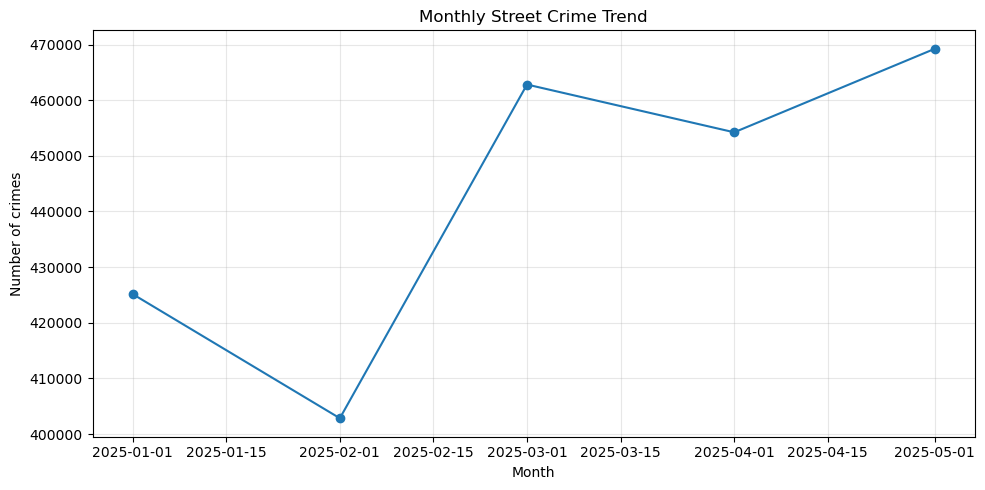

In [ ]:


# ---- Robust month extraction (df3 has either 'date' or 'month' = 'YYYY-MM')
if 'date' in df3.columns:
    # ensure datetime
    df3['date'] = pd.to_datetime(df3['date'], errors='coerce')
    month_index = df3['date'].dt.to_period('M').dt.to_timestamp()
elif 'month' in df3.columns:
    # police street files often have 'month' as YYYY-MM string
    month_index = pd.to_datetime(df3['month'], format='%Y-%m', errors='coerce')
else:
    raise KeyError("Neither 'date' nor 'month' found in df3. Add one of these in 3.1.")

# ---- Monthly count
monthly_counts = (
    pd.Series(1, index=month_index)
      .groupby(level=0).sum()
      .sort_index()
)

# ---- Plot
plt.figure(figsize=(10,5))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o')
plt.title("Monthly Street Crime Trend")
plt.xlabel("Month")
plt.ylabel("Number of crimes")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


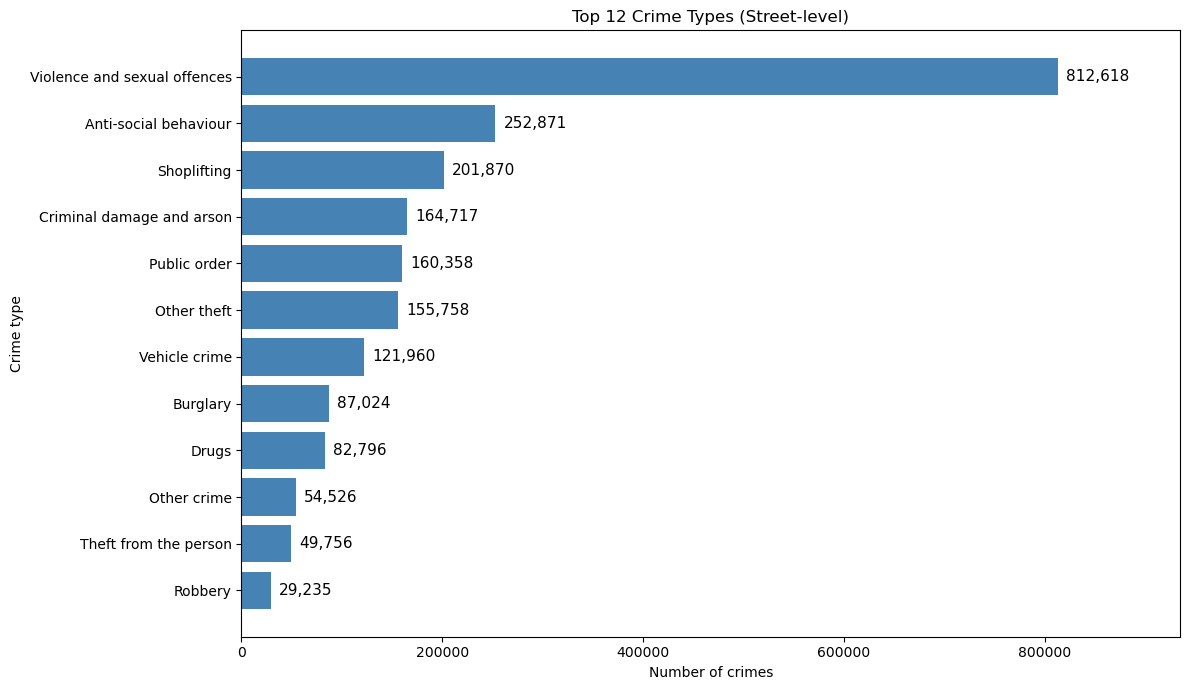

In [ ]:

# ---- Top N crime types
N = 12
type_counts = (
    df3[type_col]
      .fillna("Unknown")
      .value_counts()
      .head(N)
      .sort_values(ascending=True)
)

plt.figure(figsize=(12,7))
bars = plt.barh(type_counts.index, type_counts.values, color="steelblue")

# ---- Annotate numbers OUTSIDE in black
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (0.01 * max(type_counts.values)),  # offset outside bar
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va="center", ha="left", color="black", fontsize=11
    )

# ---- Add 15% buffer to the right so labels fit
plt.xlim(0, max(type_counts.values) * 1.15)

plt.title(f"Top {N} Crime Types (Street-level)")
plt.xlabel("Number of crimes")
plt.ylabel("Crime type")
plt.tight_layout()
plt.show()



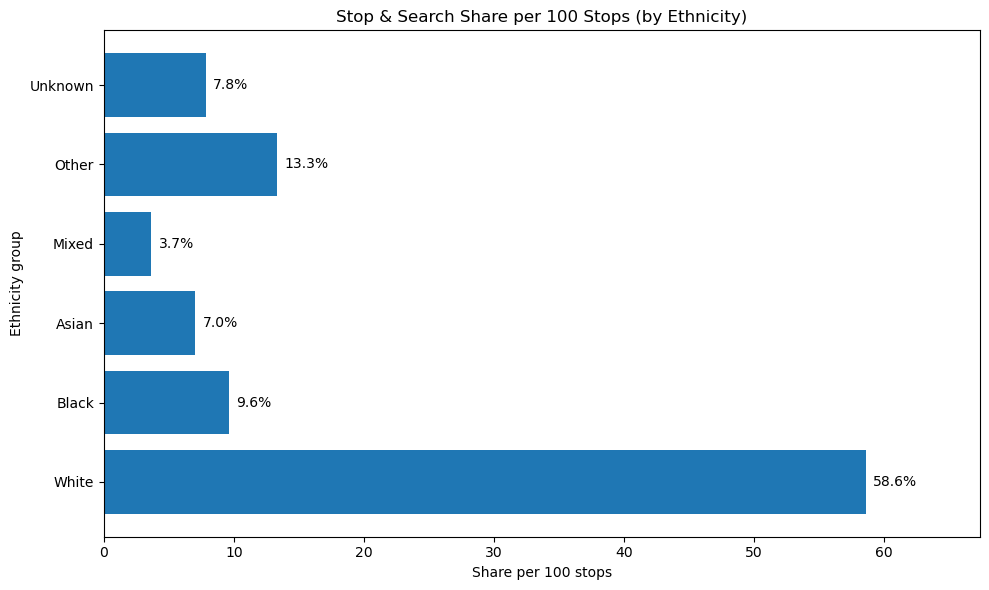

In [ ]:
# ---------- 1) Ensure we have a broad ethnicity column ----------
def map_ethnicity(x: str) -> str:
    if pd.isna(x) or x == "Unknown":
        return "Unknown"
    s = str(x).lower()
    if "white and" in s or "mixed" in s or "multiple ethnic" in s:
        return "Mixed"
    if s.startswith("white") or "any other white" in s or "irish" in s:
        return "White"
    if "black" in s or "african" in s or "caribbean" in s:
        return "Black"
    if ("asian" in s) or ("chinese" in s) or ("indian" in s) or ("pakistani" in s) or ("bangladeshi" in s):
        return "Asian"
    if "arab" in s or "gypsy" in s or "traveller" in s or "other ethnic" in s:
        return "Other"
    return "Other"

if "eth_group" not in df2.columns:
    src_col = "self-defined_ethnicity" if "self-defined_ethnicity" in df2.columns else "self-defined_ethnicity"
    # If your column name has a hyphen (e.g. 'self-defined_ethnicity'), pandas still handles it as a normal string key.
    df2["eth_group"] = df2[src_col].apply(map_ethnicity)

# Order for plotting
order = ["White","Black","Asian","Mixed","Other","Unknown"]

# ---------- 2) Counts by ethnicity ----------
counts = (df2["eth_group"]
          .fillna("Unknown")
          .value_counts()
          .reindex(order)
          .fillna(0)
          .astype(int))

# ---------- 3A) If you have population denominators: per 1,000 population ----------
# Provide population denominators in a dict. Example values below are placeholders.
# Replace with your actual denominators (e.g., England & Wales population by broad group).
eth_pop = None  # <-- set to a dict like {"White": 47000000, "Black": 2500000, ...} when available

if isinstance(eth_pop, dict):
    pop = pd.Series(eth_pop).reindex(order).astype(float)
    # avoid divide-by-zero
    rates_per_1000 = (counts / pop * 1000).replace([np.inf, -np.inf], np.nan)
    y = rates_per_1000
    title = "Stop & Search Rate per 1,000 Population (by Ethnicity)"
    xlab = "Rate per 1,000 population"
else:
    # ---------- 3B) Fallback: per 100 stops (share) ----------
    share = counts / counts.sum() * 100
    y = share
    title = "Stop & Search Share per 100 Stops (by Ethnicity)"
    xlab = "Share per 100 stops"

# ---------- 4) Plot ----------
plt.figure(figsize=(10, 6))
bars = plt.barh(y.index, y.values)

# annotate to the right, in black
xmax = np.nanmax(y.values) if len(y.values) else 0
plt.xlim(0, xmax * 1.15 if xmax > 0 else 1)

for bar in bars:
    width = bar.get_width()
    label = f"{width:,.2f}" if isinstance(eth_pop, dict) else f"{width:.1f}%"
    plt.text(width + (0.01 * (xmax if xmax > 0 else 1)),
             bar.get_y() + bar.get_height()/2,
             label, va="center", ha="left", color="black", fontsize=10)

plt.title(title)
plt.xlabel(xlab)
plt.ylabel("Ethnicity group")
plt.tight_layout()
plt.show()


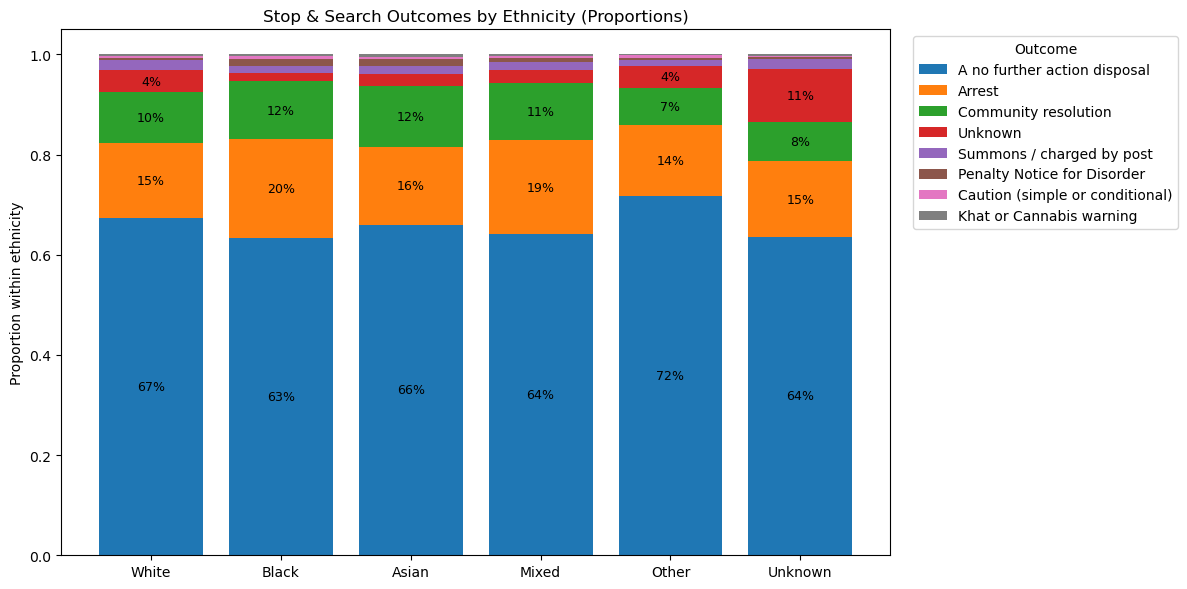

In [ ]:
# Columns present?
eth_col = "eth_group" if "eth_group" in df2.columns else None
if eth_col is None:
    raise KeyError("No 'eth_group' column found. Run the ethnicity mapping step used for Figure 3 first.")

if "outcome" not in df2.columns:
    # Some schemas use 'outcome_type' instead
    out_col = "outcome_type" if "outcome_type" in df2.columns else None
    if out_col is None:
        raise KeyError("Neither 'outcome' nor 'outcome_type' found in df2.")
    else:
        df2 = df2.rename(columns={out_col: "outcome"})

# Optional: unify unknown text variants
df2["outcome"] = df2["outcome"].fillna("Unknown")

# Order
row_order = ["White","Black","Asian","Mixed","Other","Unknown"]

# Build row-normalised table of proportions
tab = (df2.groupby(eth_col)["outcome"]
         .value_counts(normalize=True)
         .rename("prop")
         .reset_index()
         .pivot(index=eth_col, columns="outcome", values="prop")
         .fillna(0))

# Keep a manageable set of outcome columns (top K by overall frequency)
K = 8
top_cols = (df2["outcome"].value_counts().index[:K]).tolist()
tab = tab.reindex(columns=top_cols).fillna(0)

# Ensure row order
tab = tab.reindex(row_order).fillna(0)

# Plot stacked bars
plt.figure(figsize=(12, 6))
bottom = np.zeros(len(tab))
x = np.arange(len(tab.index))

for col in tab.columns:
    vals = tab[col].values
    plt.bar(x, vals, bottom=bottom, label=col)
    bottom += vals

# X-axis labels
plt.xticks(x, tab.index, rotation=0)
plt.ylabel("Proportion within ethnicity")
plt.title("Stop & Search Outcomes by Ethnicity (Proportions)")

# Legend to the right
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Outcome")

# Annotate percentages inside stacks (only if segment >= 3%)
for i in range(len(tab.index)):
    cum = 0
    for col in tab.columns:
        v = tab.iloc[i][col]
        if v >= 0.03:
            plt.text(i, cum + v/2, f"{v:.0%}", ha="center", va="center", fontsize=9, color="black")
        cum += v

plt.tight_layout()
plt.show()


posx and posy should be finite values
posx and posy should be finite values


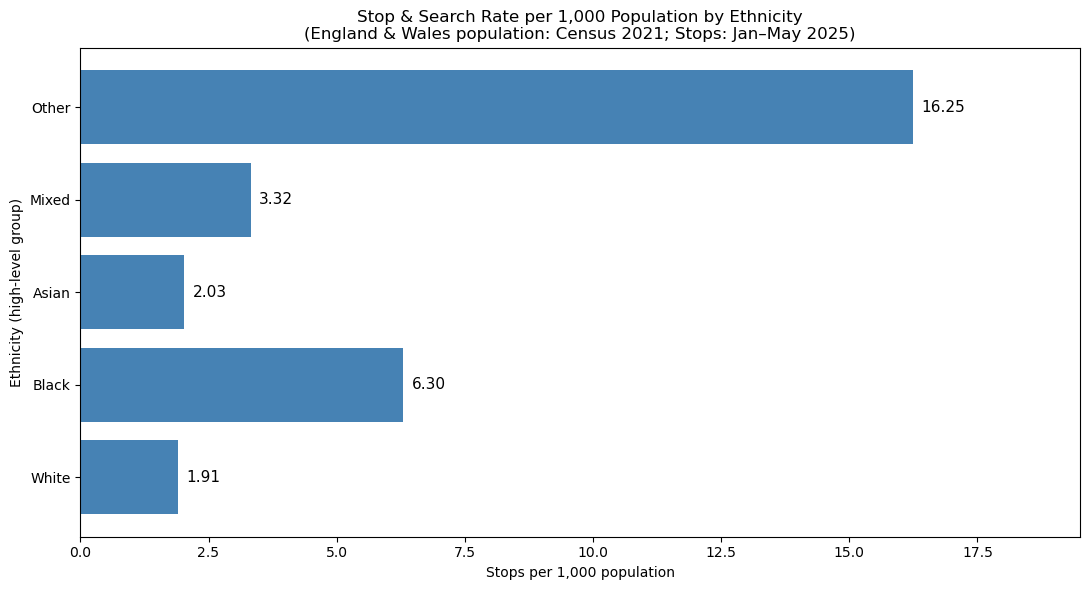

In [ ]:
# 1) Broad ethnicity mapping (same as before)
def map_ethnicity(x: str) -> str:
    if pd.isna(x) or x == "Unknown":
        return "Unknown"
    s = str(x).lower()
    if "white and" in s or "mixed" in s or "multiple ethnic" in s:
        return "Mixed"
    if s.startswith("white") or "any other white" in s or "irish" in s:
        return "White"
    if "black" in s or "african" in s or "caribbean" in s:
        return "Black"
    if "asian" in s or "chinese" in s or "indian" in s or "pakistani" in s or "bangladeshi" in s:
        return "Asian"
    if "arab" in s or "gypsy" in s or "traveller" in s or "other ethnic" in s:
        return "Other"
    return "Other"

if "eth_group" not in df2.columns:
    src_col = "self-defined_ethnicity" if "self-defined_ethnicity" in df2.columns else "self-defined_ethnicity"
    df2["eth_group"] = df2[src_col].apply(map_ethnicity)

order = ["White","Black","Asian","Mixed","Other","Unknown"]

# 2) 2021 Census denominators (England & Wales, high-level groups)
# Derived from ONS 2021 Census bulletin figures you provided:
# White 48.7m (81.7%), Asian 5.5m (9.3%), Other 1.3m (2.1%).
# Black combined from England 2.4m (4.2%) + Wales 28k (0.9%) ≈ 2.428m (~4.1% total).
# Mixed combined from England 1.7m (3.0%) + Wales 49k (1.6%) ≈ 1.749m (~2.9% total).
eth_pop_2021 = {
    "White": 48_700_000,
    "Black": 2_428_000,
    "Asian": 5_500_000,
    "Mixed": 1_749_000,
    "Other": 1_300_000,
    "Unknown": np.nan  # no denominator
}

# 3) Count stops and compute per-1,000 rates
counts = (df2["eth_group"]
          .fillna("Unknown")
          .value_counts()
          .reindex(order)
          .fillna(0)
          .astype(int))

pop = pd.Series(eth_pop_2021).reindex(order).astype(float)
rates_per_1000 = (counts / pop * 1000).replace([np.inf, -np.inf], np.nan).round(2)

# 4) Plot
plt.figure(figsize=(11,6))
bars = plt.barh(rates_per_1000.index, rates_per_1000.values, color="steelblue")

xmax = np.nanmax(np.where(np.isnan(rates_per_1000.values), 0, rates_per_1000.values))
plt.xlim(0, xmax * 1.20 if xmax > 0 else 1)

for bar in bars:
    val = bar.get_width()
    label = "n/a" if np.isnan(val) else f"{val:.2f}"
    plt.text(val + (0.01 * (xmax if xmax > 0 else 1)),
             bar.get_y() + bar.get_height()/2,
             label, va="center", ha="left", color="black", fontsize=11)

plt.title("Stop & Search Rate per 1,000 Population by Ethnicity\n(England & Wales population: Census 2021; Stops: Jan–May 2025)")
plt.xlabel("Stops per 1,000 population")
plt.ylabel("Ethnicity (high-level group)")
plt.tight_layout()
plt.show()


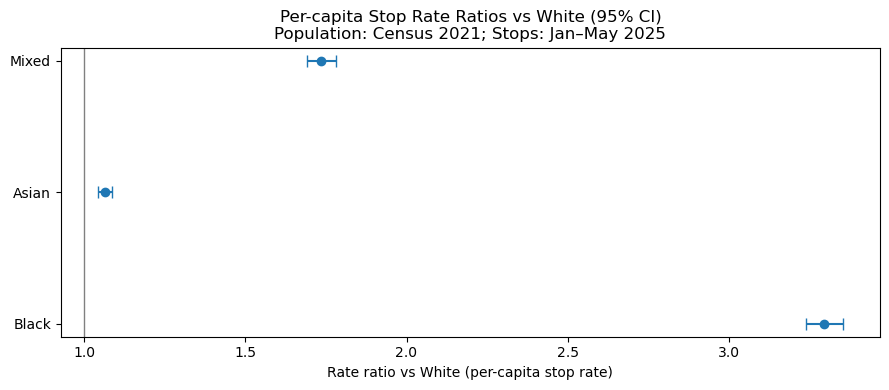

   group  stops  population  rate_per_1000  RR_vs_White  CI_low  CI_high    p
0  White  93124    48700000          1.912        1.000   0.991    1.009  1.0
1  Black  15303     2428000          6.303        3.296   3.240    3.353  0.0
2  Asian  11191     5500000          2.035        1.064   1.043    1.085  0.0
3  Mixed   5804     1749000          3.318        1.735   1.690    1.782  0.0


In [ ]:
# --- Inputs expected ---
# df2: Stop & Search with a column `eth_group` in {'White','Black','Asian','Mixed','Other','Unknown',...}
# eth_pop_2021: dict with populations for high-level groups (E&W 2021), e.g.:
# eth_pop_2021 = {'White': 48_700_000, 'Black': 2_400_000, 'Asian': 5_500_000, 'Mixed': 1_700_000}

valid_groups = ['White','Black','Asian','Mixed']
pop = {g: eth_pop_2021[g] for g in valid_groups}

stops = df2[df2['eth_group'].isin(valid_groups)]['eth_group'].value_counts().reindex(valid_groups).fillna(0).astype(int)

rates_per1000 = (stops / pd.Series(pop)) * 1000

# Poisson rate ratios vs White
base = 'White'
rows = []
for g in valid_groups:
    x1, t1 = stops[g], pop[g]
    x0, t0 = stops[base], pop[base]
    rr = (x1/t1) / (x0/t0)
    # Wald CI for log(RR)
    se = np.sqrt(1/x1 + 1/x0) if (x1>0 and x0>0) else np.nan
    if np.isfinite(se):
        z = stats.norm.ppf(0.975)
        lo, hi = np.exp(np.log(rr) - z*se), np.exp(np.log(rr) + z*se)
        p = 2*(1 - stats.norm.cdf(abs(np.log(rr)/se)))
    else:
        lo = hi = p = np.nan
    rows.append([g, stops[g], pop[g], rates_per1000[g], rr, lo, hi, p])

rr_tbl = pd.DataFrame(rows, columns=['group','stops','population','rate_per_1000','RR_vs_White','CI_low','CI_high','p'])

# Forest plot
fig, ax = plt.subplots(figsize=(9,4))
plot_df = rr_tbl.set_index('group').loc[[g for g in valid_groups if g!=base]]
ax.errorbar(plot_df['RR_vs_White'], plot_df.index, 
            xerr=[plot_df['RR_vs_White']-plot_df['CI_low'], plot_df['CI_high']-plot_df['RR_vs_White']],
            fmt='o', capsize=4)
ax.axvline(1.0, color='grey', lw=1)
ax.set_xlabel('Rate ratio vs White (per-capita stop rate)')
ax.set_title('Per-capita Stop Rate Ratios vs White (95% CI)\nPopulation: Census 2021; Stops: Jan–May 2025')
plt.tight_layout()
plt.show()

print(rr_tbl.round(3))


Chi-square = 1150.8, df=21, p-value=1.91e-230
Cramér's V = 0.055


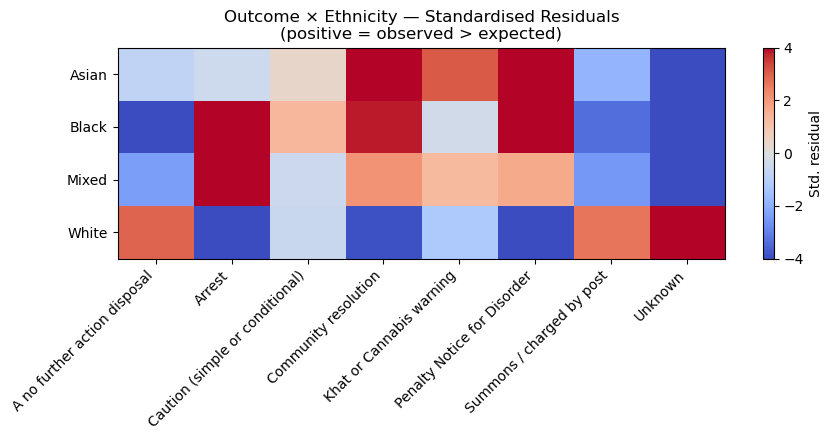

In [ ]:
# Filter data
keep = ['White','Black','Asian','Mixed']
df_out = df2[df2['eth_group'].isin(keep)].copy()

# Clean minimal outcomes (you can collapse if needed)
# Example: keep "Arrest" and "No further action" plus top others
# If your column is named 'outcome' already tidy
tab = pd.crosstab(df_out['eth_group'], df_out['outcome'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(tab.values)
n = tab.values.sum()
# Cramér's V
phi2 = chi2 / n
r, c = tab.shape
cramers_v = np.sqrt(phi2 / min(r-1, c-1))

print(f"Chi-square = {chi2:.1f}, df={dof}, p-value={p:.3g}")
print(f"Cramér's V = {cramers_v:.3f}")

# Standardised residuals
std_resid = (tab.values - expected) / np.sqrt(expected)
resid_df = pd.DataFrame(std_resid, index=tab.index, columns=tab.columns)

# Heatmap (matplotlib only)
fig, ax = plt.subplots(figsize=(9,4.5))
im = ax.imshow(resid_df.values, aspect='auto', cmap='coolwarm', vmin=-4, vmax=4)
ax.set_xticks(range(resid_df.shape[1])); ax.set_xticklabels(resid_df.columns, rotation=45, ha='right')
ax.set_yticks(range(resid_df.shape[0])); ax.set_yticklabels(resid_df.index)
ax.set_title("Outcome × Ethnicity — Standardised Residuals\n(positive = observed > expected)")
cbar = plt.colorbar(im, ax=ax); cbar.set_label('Std. residual')
plt.tight_layout(); plt.show()


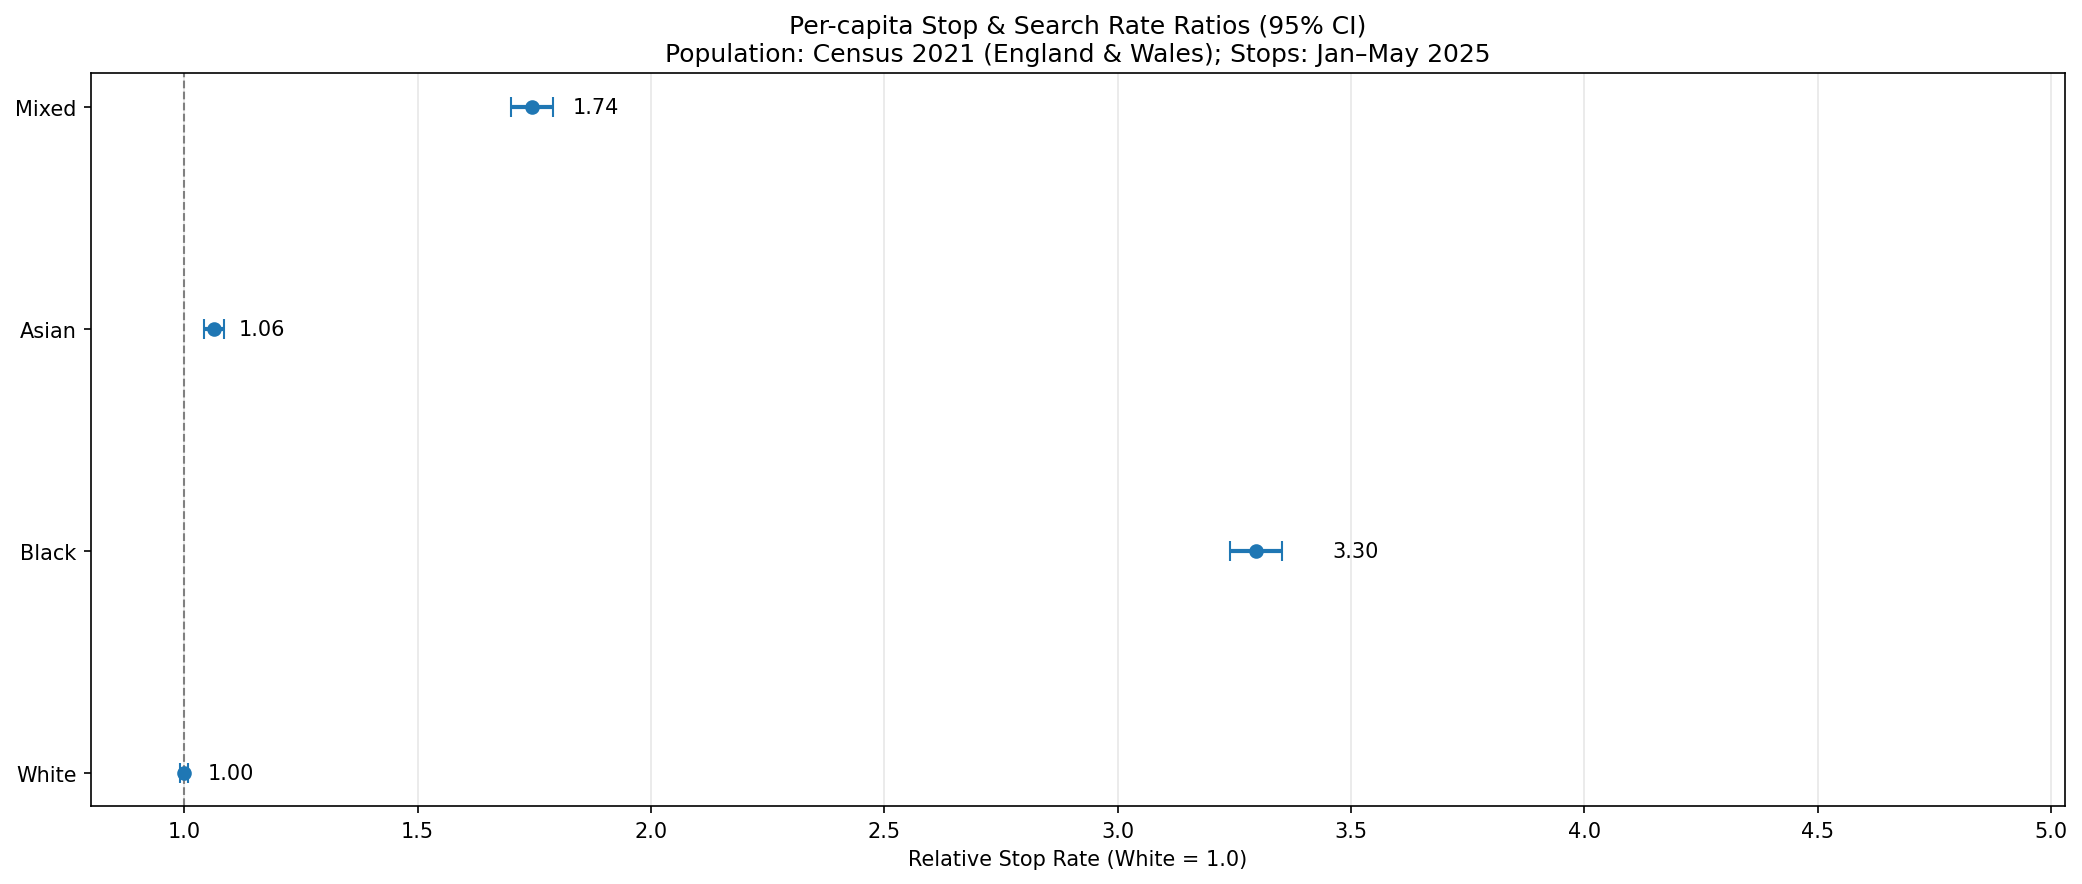

In [117]:
fig, ax = plt.subplots(figsize=(14, 6), dpi=150)

y = np.arange(len(df_plot))
ax.errorbar(df_plot["RR_vs_White"], y,
            xerr=[df_plot["RR_vs_White"]-df_plot["CI_low"],
                  df_plot["CI_high"]-df_plot["RR_vs_White"]],
            fmt='o', capsize=5, elinewidth=2, markersize=6, color="tab:blue")

# Reference line (White baseline = 1.0)
ax.axvline(1.0, color='grey', lw=1, linestyle='--')

# Axis ticks and labels
ax.set_yticks(y, df_plot["group"])
ax.set_xlabel("Relative Stop Rate (White = 1.0)")
ax.set_title("Per-capita Stop & Search Rate Ratios (95% CI)\n"
             "Population: Census 2021 (England & Wales); Stops: Jan–May 2025")

# Annotate: offset scales with value (so bigger values get more space)
for i, row in df_plot.iterrows():
    ax.text(row["RR_vs_White"] + row["RR_vs_White"]*0.05, y[i],  # dynamic offset
            f'{row["RR_vs_White"]:.2f}', ha='left', va='center',
            fontsize=10, color="black")

# Expand x-axis for breathing room
ax.set_xlim(left=0.8, right=max(df_plot["CI_high"])*1.5)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


<Axes: title={'center': 'Top 10 Crime Types (Jan–May 2025)'}, xlabel='crime_type'>

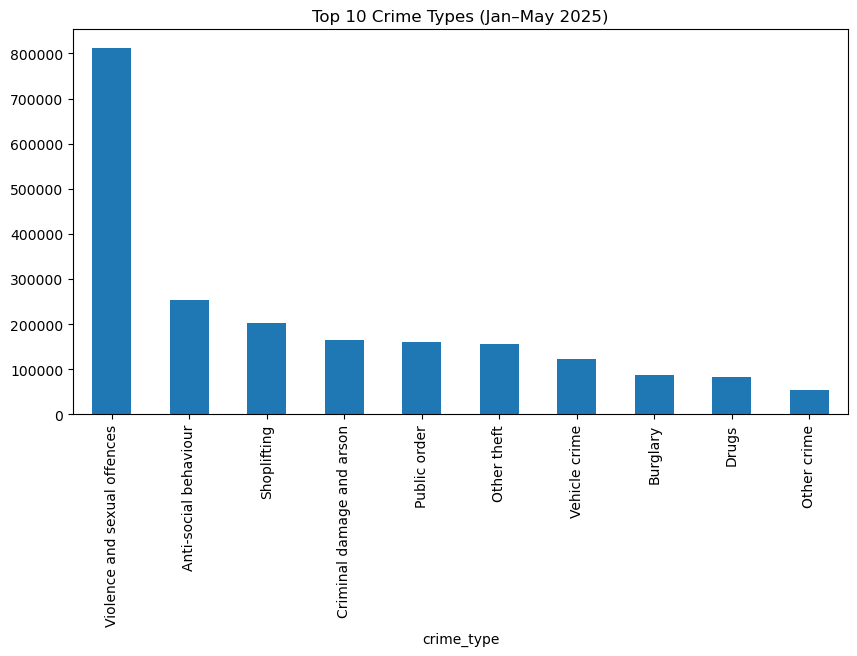

In [55]:
df3["crime_type"].value_counts().head(10).plot(kind="bar", figsize=(10,5), title="Top 10 Crime Types (Jan–May 2025)")


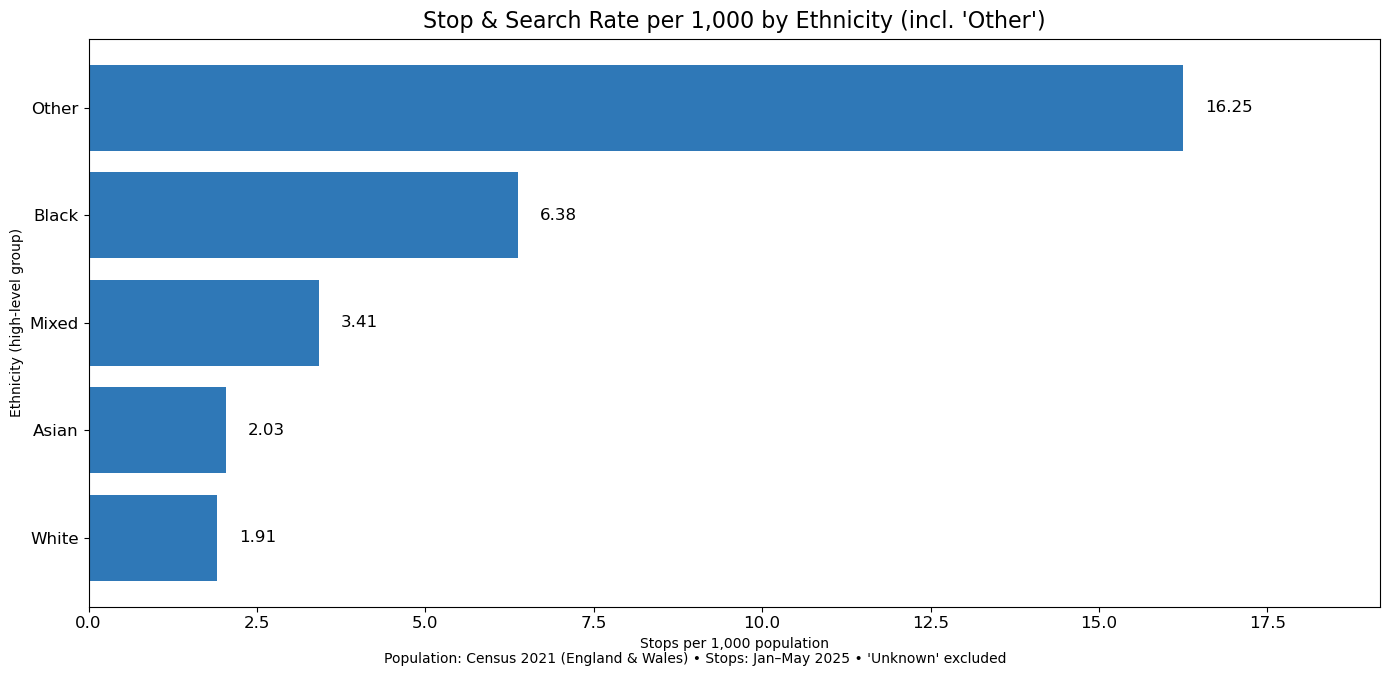

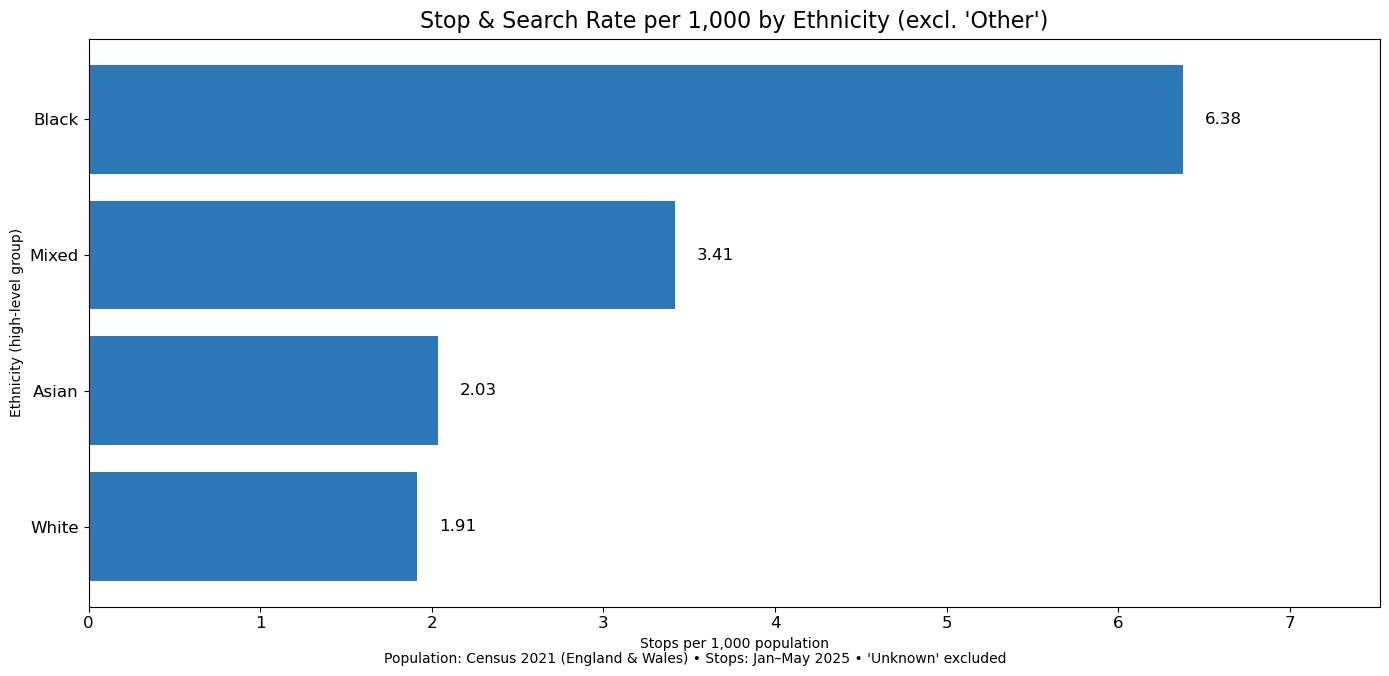

In [ ]:
# ---------- 1) Ethnicity mapping (keeps Unknown separate) ----------
if "eth_group" not in df2.columns:
    def map_ethnicity(x: str) -> str:
        if pd.isna(x): 
            return "Unknown"
        s = str(x).strip().lower()
        # clear Unknown-like
        if s in {"unknown", "not stated", "refused", "prefer not to say", "not known"}:
            return "Unknown"
        # mixed / multiple
        if "mixed" in s or "multiple" in s or "white and" in s:
            return "Mixed"
        # white
        if s.startswith("white") or "any other white" in s or "irish" in s or s == "british":
            return "White"
        # black
        if "black" in s or "african" in s or "caribbean" in s:
            return "Black"
        # asian
        if "asian" in s or "chinese" in s or "indian" in s or "pakistani" in s or "bangladeshi" in s:
            return "Asian"
        # arab/gypsy/traveller etc. remain Other (as per ONS high-level)
        if "arab" in s or "gypsy" in s or "traveller" in s or "romany" in s or "roma" in s or "other" in s:
            return "Other"
        return "Other"

    df2["eth_group"] = df2["self-defined_ethnicity"].apply(map_ethnicity)

# ---------- 2) Census 2021 population (England & Wales) ----------
# High-level ONS groups
census_pop = {
    "White": 48_700_000,  # 81.7%
    "Asian":  5_500_000,  # 9.3%
    "Black":  2_400_000,  # 4.2%
    "Mixed":  1_700_000,  # 3.0%
    "Other":  1_300_000,  # 2.2%
    # Unknown has no population denominator by definition
}

# ---------- 3) Stops by group ----------
stops_by_group = df2["eth_group"].value_counts()

def make_rate_df(include_other=True, exclude_unknown=True):
    groups = ["White", "Asian", "Black", "Mixed", "Other"]
    if not include_other:
        groups = [g for g in groups if g != "Other"]
    data = []
    for g in groups:
        stops = stops_by_group.get(g, 0)
        pop = census_pop.get(g, np.nan)
        rate = (stops / pop) * 1000 if pd.notna(pop) and pop > 0 else np.nan
        data.append((g, stops, pop, rate))
    rate_df = pd.DataFrame(data, columns=["group", "stops", "population", "rate_per_1000"])
    if exclude_unknown:
        # nothing to do here; we never added Unknown to the rate frame
        pass
    return rate_df.sort_values("rate_per_1000", ascending=True)

def plot_rates(rate_df, title, subtitle, annotate_inside=False, xscale="linear"):
    plt.figure(figsize=(14, 7), facecolor="white")
    ax = plt.gca()
    bars = ax.barh(rate_df["group"], rate_df["rate_per_1000"], color="#2f78b7")
    ax.set_title(title, fontsize=16, color="black", pad=8)
    ax.set_xlabel("Stops per 1,000 population", color="black")
    ax.set_ylabel("Ethnicity (high-level group)", color="black")
    ax.tick_params(colors="black", labelsize=12)
    for spine in ax.spines.values():
        spine.set_color("black")
    ax.set_xscale(xscale)

    # annotation: either just beyond bar end, or inside bar if you prefer
    xmax = np.nanmax(rate_df["rate_per_1000"].values) if len(rate_df) else 1.0
    for rect, val in zip(bars, rate_df["rate_per_1000"]):
        if np.isnan(val): 
            continue
        if annotate_inside:
            x = rect.get_width() * 0.98
            ha = "right"
        else:
            x = rect.get_width() + xmax * 0.02
            ha = "left"
        y = rect.get_y() + rect.get_height()/2
        ax.text(x, y, f"{val:.2f}", va="center", ha=ha, color="black", fontsize=12)

    # room on the right
    if xscale == "linear":
        ax.set_xlim(0, xmax * 1.18)

    plt.suptitle(subtitle, y=0.02, fontsize=10, color="black")
    plt.tight_layout()
    plt.show()

# ---------- 4) Figure 3a — includes "Other" (accurate but may look large) ----------
fig3a = make_rate_df(include_other=True, exclude_unknown=True)
plot_rates(
    fig3a,
    title="Stop & Search Rate per 1,000 by Ethnicity (incl. 'Other')",
    subtitle="Population: Census 2021 (England & Wales) • Stops: Jan–May 2025 • 'Unknown' excluded",
    annotate_inside=False
)

# ---------- 5) Figure 3b — excludes "Other" (clean like-for-like comparison) ----------
fig3b = make_rate_df(include_other=False, exclude_unknown=True)
plot_rates(
    fig3b,
    title="Stop & Search Rate per 1,000 by Ethnicity (excl. 'Other')",
    subtitle="Population: Census 2021 (England & Wales) • Stops: Jan–May 2025 • 'Unknown' excluded",
    annotate_inside=False
)


<Axes: title={'center': 'Top Outcomes (Jan–May 2025)'}, xlabel='outcome'>

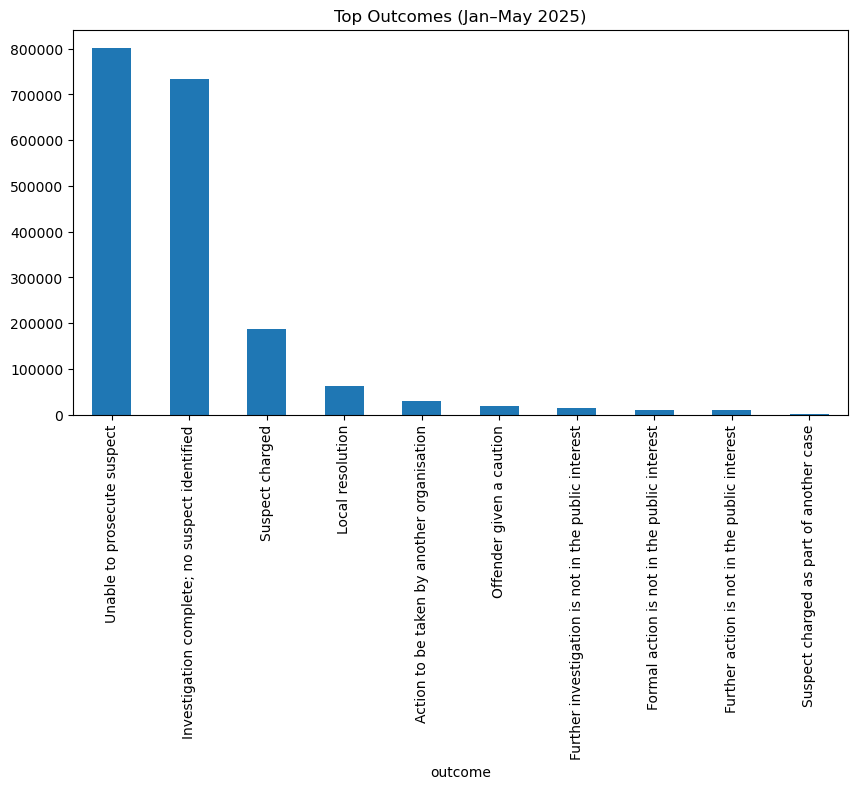

In [56]:
df1["outcome"].value_counts().head(10).plot(kind="bar", figsize=(10,5), title="Top Outcomes (Jan–May 2025)")


<Axes: title={'center': 'Crimes by Month (Outcomes data)'}, xlabel='month_name'>

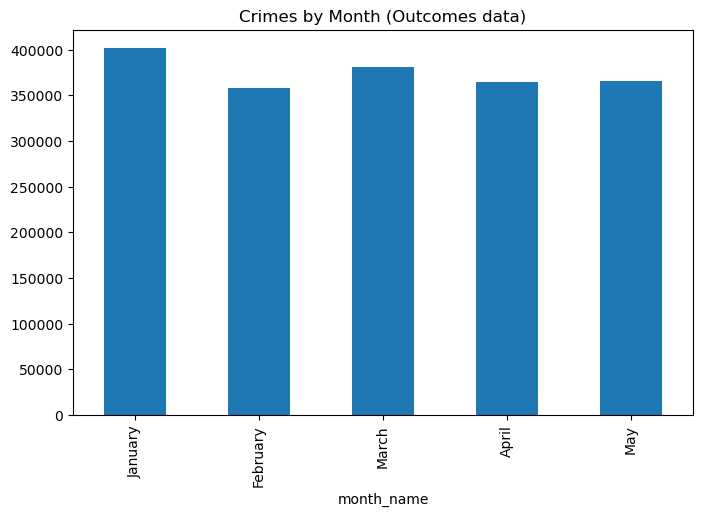

In [57]:
order = ["January", "February", "March", "April", "May"]
df1["month_name"] = pd.Categorical(df1["month_name"], categories=order, ordered=True)

df1["month_name"].value_counts().reindex(order).plot(
    kind="bar", figsize=(8,5), title="Crimes by Month (Outcomes data)"
)


<Axes: title={'center': 'Stop & Search by Day of Week'}, xlabel='day_of_week'>

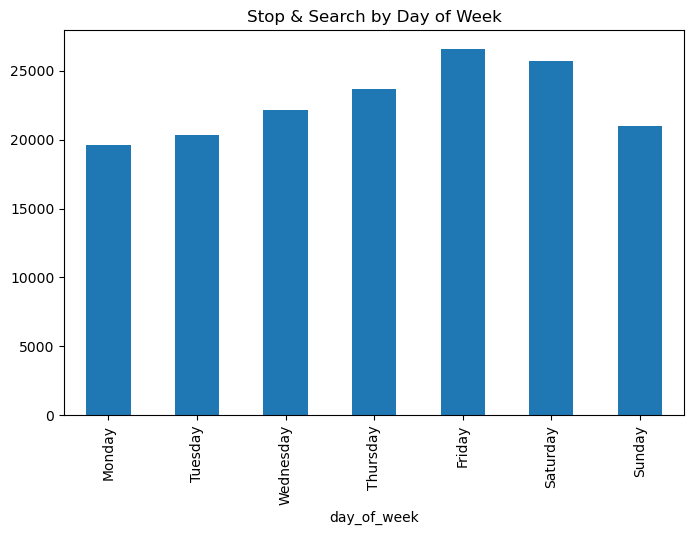

In [58]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df2["day_of_week"] = pd.Categorical(df2["day_of_week"], categories=order, ordered=True)

df2["day_of_week"].value_counts().reindex(order).plot(
    kind="bar", figsize=(8,5), title="Stop & Search by Day of Week"
)


<Axes: title={'center': 'Top 10 Locations (Street data)'}, ylabel='lsoa_name'>

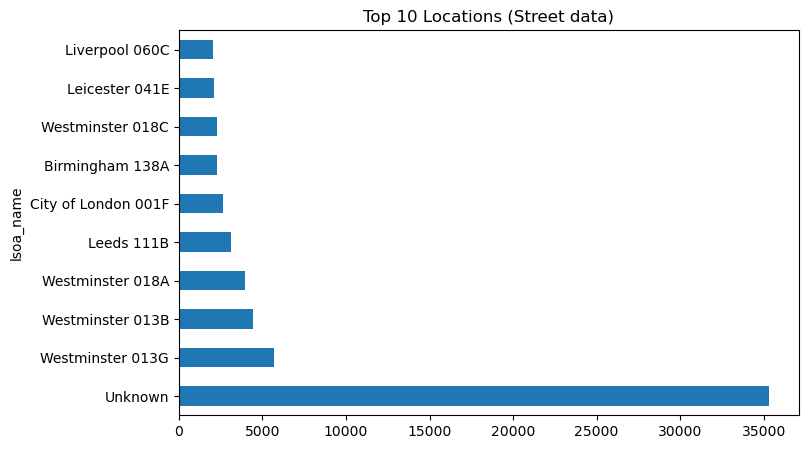

In [59]:
df3["lsoa_name"].value_counts().head(10).plot(kind="barh", figsize=(8,5), title="Top 10 Locations (Street data)")


<Axes: ylabel='outcome'>

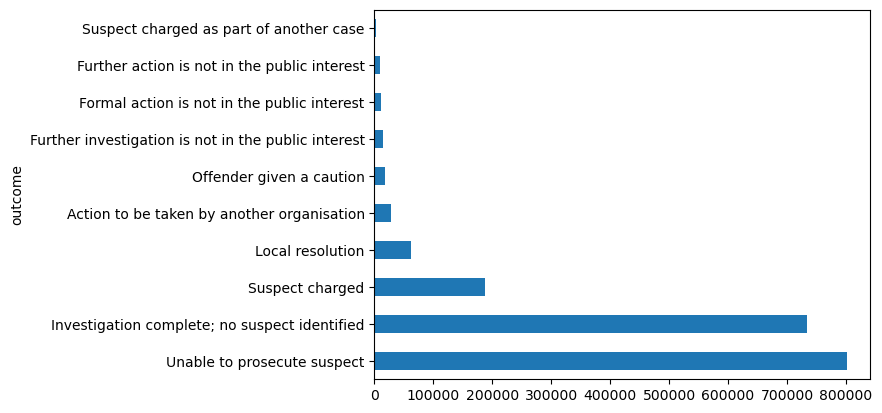

In [60]:
df1["outcome"].value_counts().head(10).plot(kind="barh")


<Axes: title={'center': 'Stop & Search Outcomes by Ethnicity'}, xlabel='self-defined_ethnicity'>

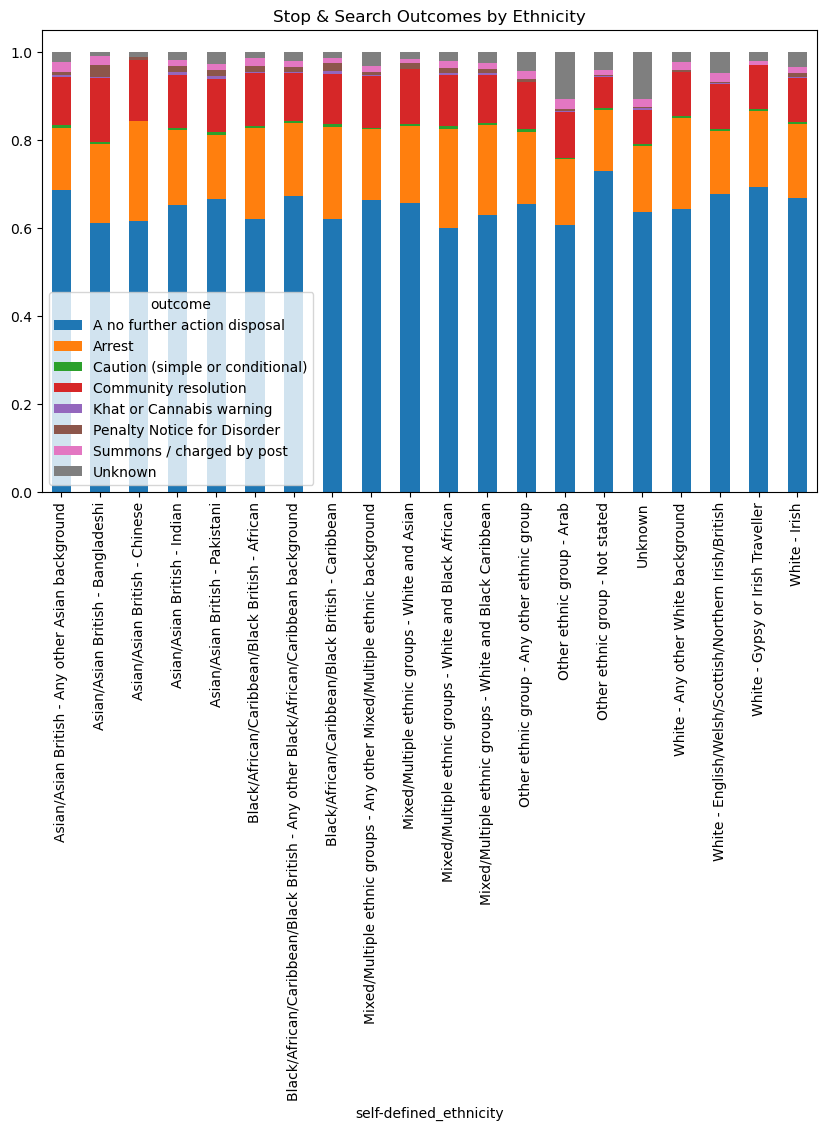

In [61]:
df2.groupby("self-defined_ethnicity")["outcome"].value_counts(normalize=True).unstack().plot( 
    kind="bar", stacked=True, figsize=(10,6), 
    title="Stop & Search Outcomes by Ethnicity"
)

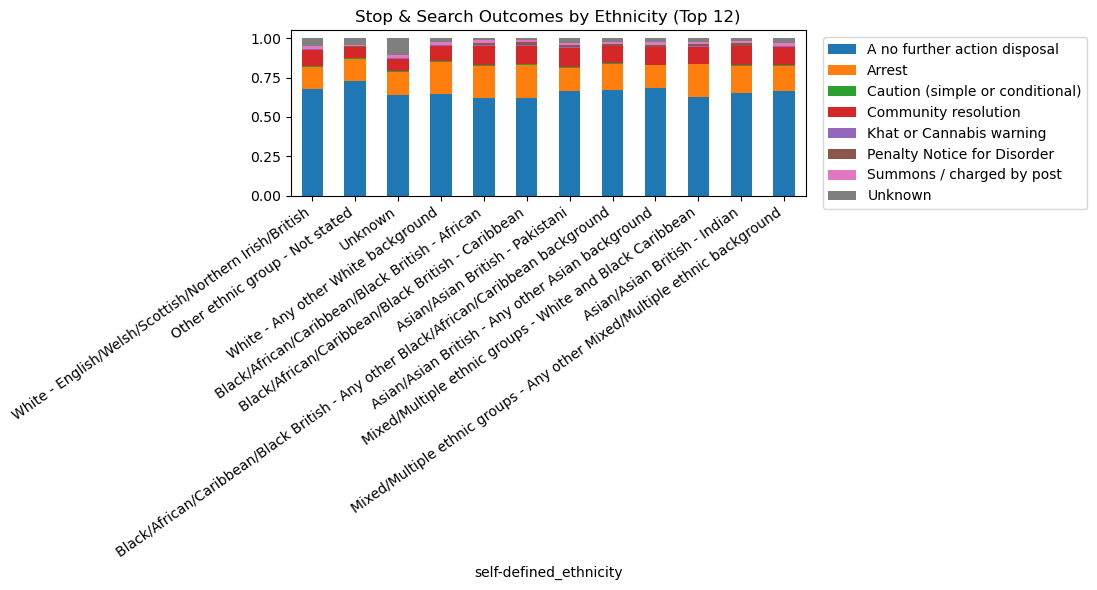

In [62]:
N = 12  # show top 12 ethnicities
order = df2["self-defined_ethnicity"].value_counts().index[:N]

ax = (df2[df2["self-defined_ethnicity"].isin(order)]
        .groupby("self-defined_ethnicity")["outcome"]
        .value_counts(normalize=True).unstack()
        .loc[order]  # keep order
        .plot(kind="bar", stacked=True, figsize=(11,6),
              title="Stop & Search Outcomes by Ethnicity (Top 12)"))

# legend to the right
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()



#### **Stop & Seach Outcomes By categorised ethinicity group**

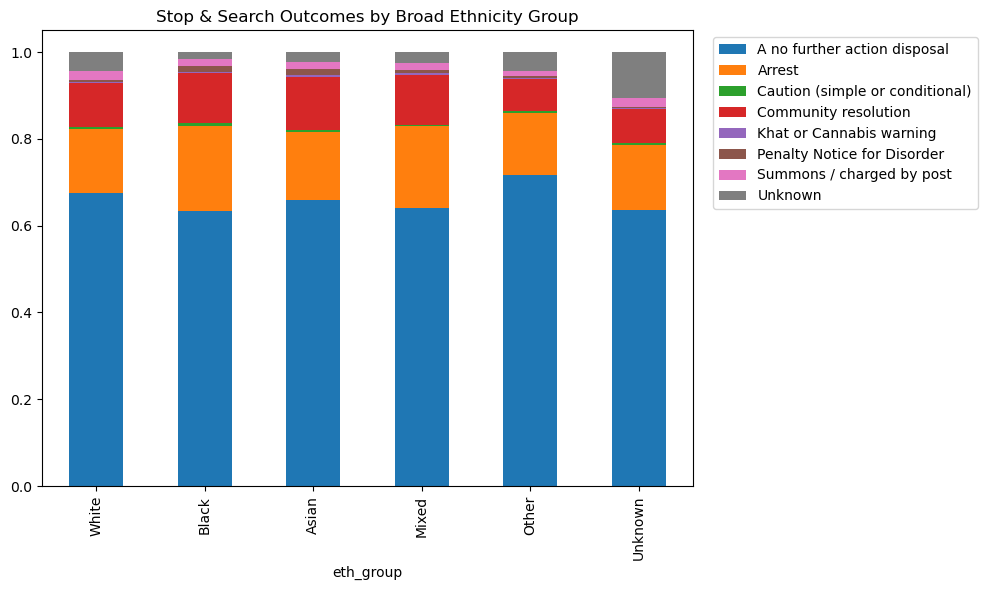

In [63]:
# stacked proportions by broad group
ax = (df2.groupby("eth_group")["outcome"]
        .value_counts(normalize=True).unstack(fill_value=0)
        .loc[["White","Black","Asian","Mixed","Other","Unknown"]]
        .plot(kind="bar", stacked=True, figsize=(10,6),
              title="Stop & Search Outcomes by Broad Ethnicity Group"))
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()


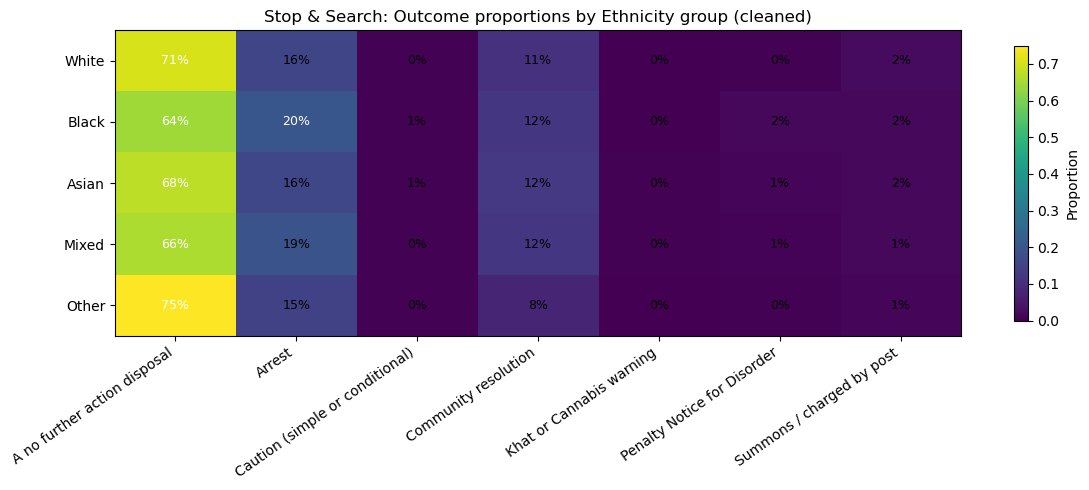

In [66]:
def heatmap_props_all(df, row="eth_group", col="outcome", order_rows=None, top_k_cols=None,
                      title="Outcome proportions by Ethnicity group"):
    # filter out Unknown outcomes
    df = df[df[col] != "Unknown"]

    # Build row-normalized table
    tab = (df.groupby(row)[col]
             .value_counts(normalize=True)
             .unstack(fill_value=0))

    # keep most common columns if requested
    if top_k_cols:
        keep = df[col].value_counts().index[:top_k_cols]
        tab = tab.reindex(columns=keep).fillna(0)

    # row order
    if order_rows is None:
        order_rows = ["White","Black","Asian","Mixed","Other"]
    tab = tab.reindex(order_rows)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(tab.values, aspect="auto", cmap="viridis", vmin=0, vmax=tab.values.max())

    # Axes ticks/labels
    ax.set_xticks(range(tab.shape[1])); ax.set_xticklabels(tab.columns, rotation=35, ha="right")
    ax.set_yticks(range(tab.shape[0])); ax.set_yticklabels(tab.index)
    ax.set_title(title)
    cbar = plt.colorbar(im, ax=ax, shrink=0.9); cbar.set_label("Proportion")

    # Annotate all cells with %
    for i in range(tab.shape[0]):
        for j in range(tab.shape[1]):
            val = tab.values[i, j]
            ax.text(j, i, f"{val:.0%}", color="white" if val > 0.2 else "black",
                    ha="center", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()
    return tab

# Run updated heatmap
_ = heatmap_props_all(df2, row="eth_group", col="outcome",
                      title="Stop & Search: Outcome proportions by Ethnicity group (cleaned)")


### **Unknown back**

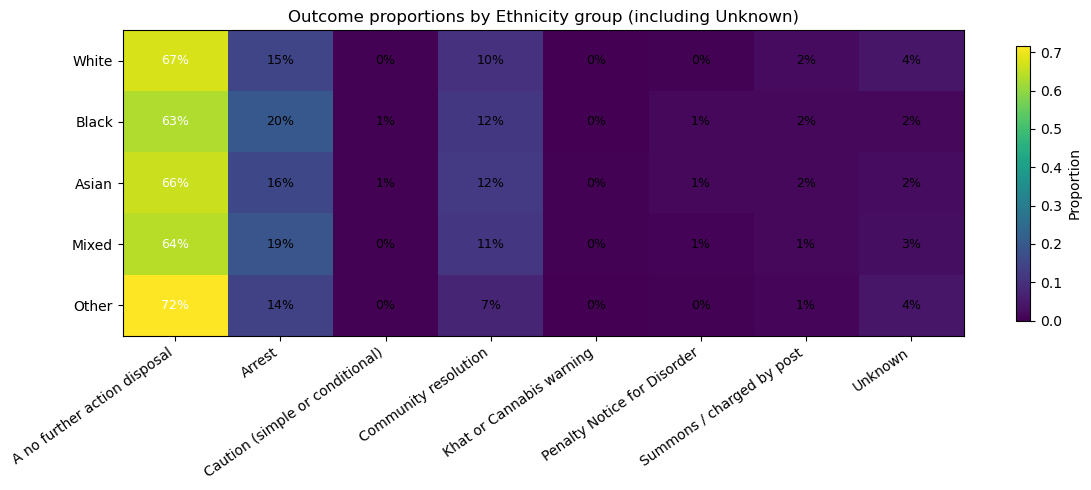

In [67]:
def heatmap_props_all_with_unknown(df, row="eth_group", col="outcome", order_rows=None, top_k_cols=None,
                                   title="Outcome proportions by Ethnicity group (including Unknown)"):
    # Build row-normalized table
    tab = (df.groupby(row)[col]
             .value_counts(normalize=True)
             .unstack(fill_value=0))

    # keep most common columns if requested
    if top_k_cols:
        keep = df[col].value_counts().index[:top_k_cols]
        tab = tab.reindex(columns=keep).fillna(0)

    # row order
    if order_rows is None:
        order_rows = ["White","Black","Asian","Mixed","Other"]
    tab = tab.reindex(order_rows)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(tab.values, aspect="auto", cmap="viridis", vmin=0, vmax=tab.values.max())

    # Axes ticks/labels
    ax.set_xticks(range(tab.shape[1])); ax.set_xticklabels(tab.columns, rotation=35, ha="right")
    ax.set_yticks(range(tab.shape[0])); ax.set_yticklabels(tab.index)
    ax.set_title(title)
    cbar = plt.colorbar(im, ax=ax, shrink=0.9); cbar.set_label("Proportion")

    # Annotate all cells with %
    for i in range(tab.shape[0]):
        for j in range(tab.shape[1]):
            val = tab.values[i, j]
            ax.text(j, i, f"{val:.0%}", color="white" if val > 0.2 else "black",
                    ha="center", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()
    return tab

# Run with Unknown included
_ = heatmap_props_all_with_unknown(df2, row="eth_group", col="outcome")


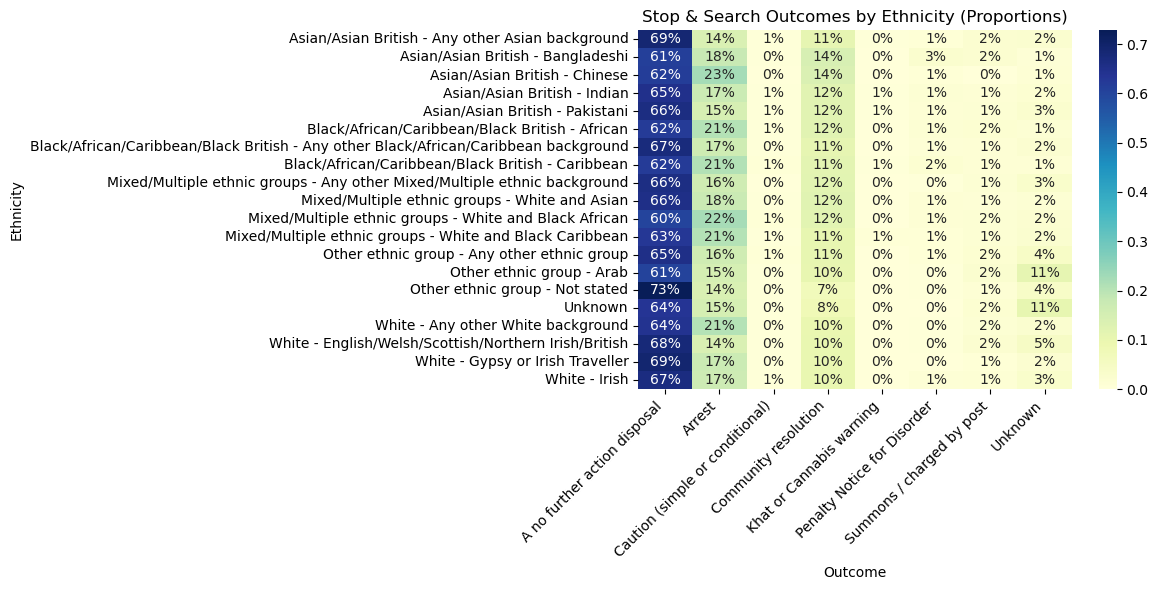

In [68]:
# Group by ethnicity and outcome
race_outcome = (
    df2.groupby("self-defined_ethnicity")["outcome"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

plt.figure(figsize=(12,6))
sns.heatmap(race_outcome, annot=True, fmt=".0%", cmap="YlGnBu")
plt.title("Stop & Search Outcomes by Ethnicity (Proportions)")
plt.ylabel("Ethnicity")
plt.xlabel("Outcome")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


C:\Users\Sarunas\AppData\Local\Temp\ipykernel_10752\909434222.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  hour_day = df2.pivot_table(


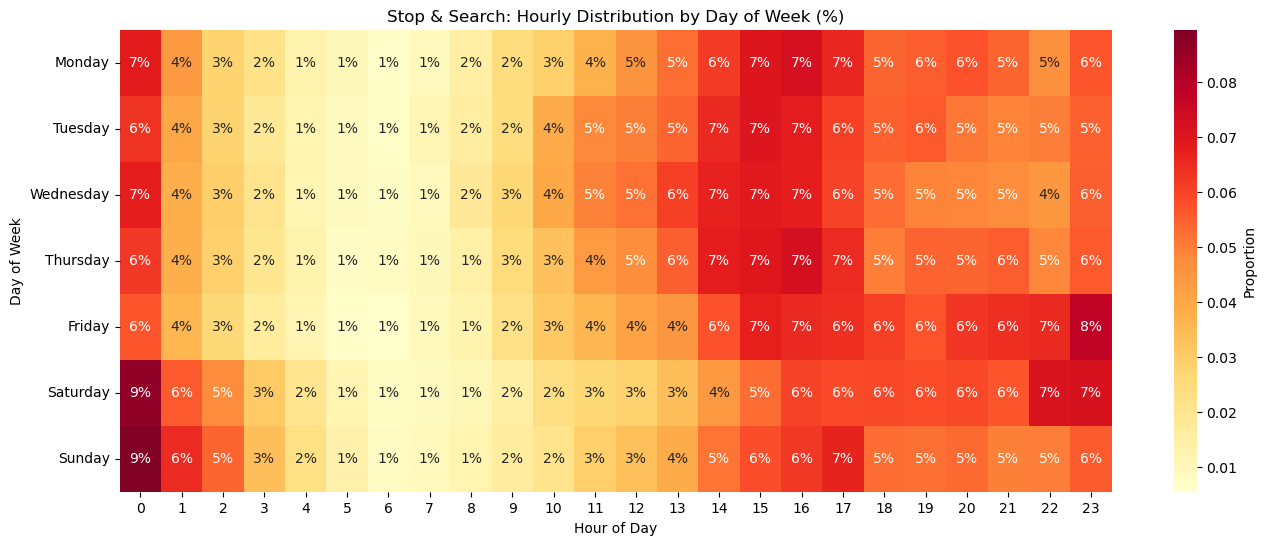

In [69]:
# Extract hour of day
df2["hour"] = df2["date"].dt.hour

# Count searches
hour_day = df2.pivot_table(
    index="day_of_week", columns="hour", values="outcome", aggfunc="count"
).fillna(0)

# Reorder weekdays
days_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
hour_day = hour_day.reindex(days_order)

# Convert to percentages row-wise (per day)
hour_day_pct = hour_day.div(hour_day.sum(axis=1), axis=0)

plt.figure(figsize=(16,6))
sns.heatmap(hour_day_pct, annot=True, fmt=".0%", cmap="YlOrRd", cbar_kws={'label': 'Proportion'})
plt.title("Stop & Search: Hourly Distribution by Day of Week (%)")
plt.ylabel("Day of Week")
plt.xlabel("Hour of Day")
plt.xticks(ticks=[i+0.5 for i in range(24)], labels=list(range(24)), rotation=0)
plt.show()


In [70]:
# Take sample if dataset is very large
sample_df = df2.dropna(subset=["latitude","longitude"]).sample(5000, random_state=42)

# Create map centered on UK
m = folium.Map(location=[54.0, -2.0], zoom_start=6)

# Add points
for _, row in sample_df.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=2,
        color="red",
        fill=True,
        fill_opacity=0.6,
        popup=row["outcome"]
    ).add_to(m)

m.save("stop_search_map.html")


In [71]:
def make_point_map(
    df, lat="latitude", lon="longitude", label_cols=("outcome","type"),
    max_points=10000, filename="map.html", start=[54.0,-2.0], zoom=6
):
    d = df.dropna(subset=[lat, lon]).copy()
    if len(d) == 0:
        raise ValueError("No rows with valid lat/long.")
    if len(d) > max_points:
        d = d.sample(max_points, random_state=42)

    # Center on data if possible
    center = [d[lat].median(), d[lon].median()] if all(c in d for c in [lat, lon]) else start
    m = folium.Map(location=center, zoom_start=zoom, tiles="cartodbpositron")

    # Clustered markers layer
    cluster = MarkerCluster(name="Points (clustered)").add_to(m)
    for _, r in d.iterrows():
        popup = "<br>".join([f"{c}: {r.get(c,'')}" for c in label_cols if c in d.columns])
        folium.CircleMarker(
            [r[lat], r[lon]], radius=2, weight=0, fill=True, fill_opacity=0.7
        ).add_to(cluster).add_child(folium.Popup(popup, max_width=280))

    # Heatmap layer
    HeatMap(d[[lat, lon]].values.tolist(), name="Density heatmap", radius=6, blur=7).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    m.save(filename)
    return filename

# EXAMPLES
# Stop & Search (df2)
f1 = make_point_map(df2, filename="stop_search_map.html",
                    label_cols=("outcome","self-defined_ethnicity","legislation"))
IFrame(f1, width=1000, height=600)  # or open the HTML in your browser

# Street crimes (df3)
f2 = make_point_map(df3, filename="street_crime_map.html",
                    label_cols=("crime_type","outcome"))
IFrame(f2, width=1000, height=600)


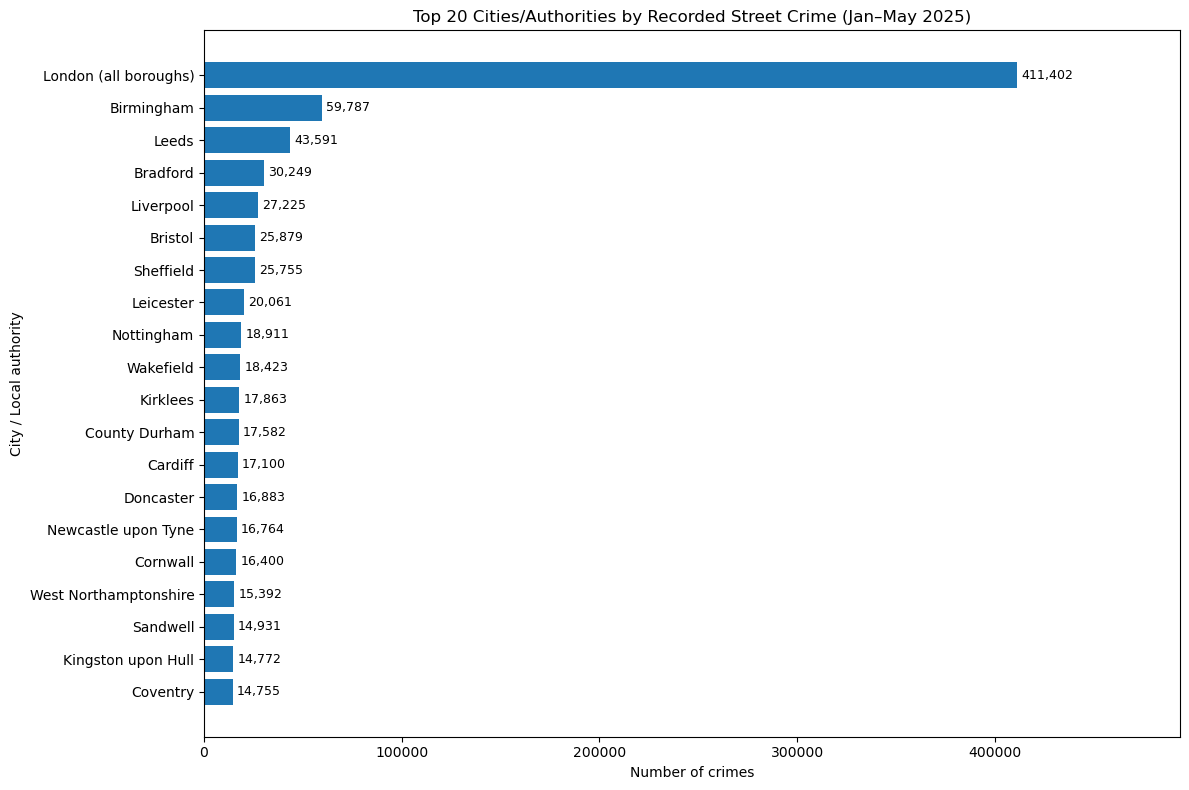

In [72]:
import matplotlib.pyplot as plt

# Example data from your chart
city_counts = {
    "London (all boroughs)": 411402,
    "Birmingham": 59787,
    "Leeds": 43591,
    "Bradford": 30249,
    "Liverpool": 27225,
    "Bristol": 25879,
    "Sheffield": 25755,
    "Leicester": 20061,
    "Nottingham": 18911,
    "Wakefield": 18423,
    "Kirklees": 17863,
    "County Durham": 17582,
    "Cardiff": 17100,
    "Doncaster": 16883,
    "Newcastle upon Tyne": 16764,
    "Cornwall": 16400,
    "West Northamptonshire": 15392,
    "Sandwell": 14931,
    "Kingston upon Hull": 14772,
    "Coventry": 14755,
}
city_counts = dict(sorted(city_counts.items(), key=lambda x: x[1]))  # sort ascending for barh

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(list(city_counts.keys()), list(city_counts.values()))

# Add labels **outside** bars
for i, v in enumerate(city_counts.values()):
    ax.text(v + 2000, i, f"{v:,}", va="center", ha="left", fontsize=9, color="black")

# Extend x-axis to allow space for labels
xmax = max(city_counts.values())
ax.set_xlim(0, xmax * 1.2)

ax.set_title("Top 20 Cities/Authorities by Recorded Street Crime (Jan–May 2025)")
ax.set_xlabel("Number of crimes")
ax.set_ylabel("City / Local authority")
plt.tight_layout()
plt.show()


In [73]:
# Filter violent crimes only
violent_crimes = df3[df3["crime_type"].str.contains("Violence", case=False, na=False)]


In [74]:
# Drop rows with missing coordinates
violent_crimes = violent_crimes.dropna(subset=["latitude", "longitude"])


In [75]:
import folium
from folium.plugins import MarkerCluster

# Center map on England
m = folium.Map(location=[52.3555, -1.1743], zoom_start=6, tiles="cartodbpositron")

# Add marker clusters
marker_cluster = MarkerCluster().add_to(m)

for _, row in violent_crimes.sample(5000, random_state=42).iterrows():  # sample to keep performance good
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=f"{row['crime_type']}<br>{row['month']}<br>{row['location']}",
        icon=folium.Icon(color="red", icon="info-sign")
    ).add_to(marker_cluster)

# Save to HTML
m.save("violent_crime_clusters.html")


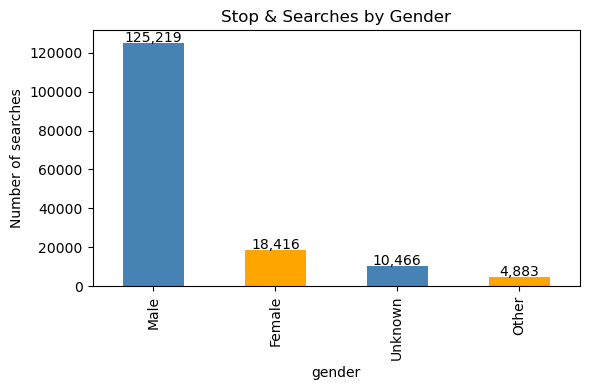

In [76]:
# Count by gender
gender_counts = df2["gender"].value_counts()

ax = gender_counts.plot(kind="bar", figsize=(6,4), color=["steelblue","orange"], title="Stop & Searches by Gender")
ax.set_ylabel("Number of searches")
for i, v in enumerate(gender_counts):
    ax.text(i, v+500, f"{v:,}", ha="center")
plt.tight_layout()
plt.show()



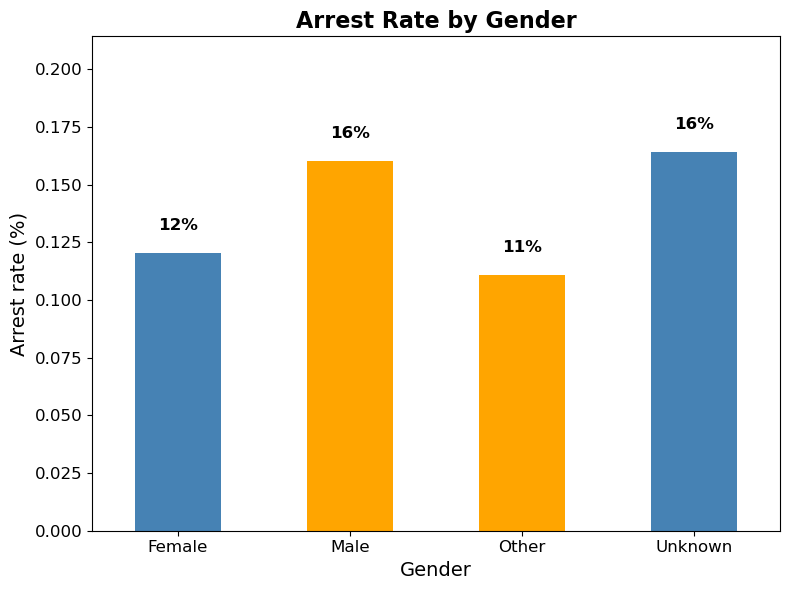

In [77]:
arrest_rate = df2.groupby("gender")["outcome"].apply(lambda x: (x=="Arrest").mean())

fig, ax = plt.subplots(figsize=(8,6))  # balanced figure size

colors = ["orange" if g in ["Male","Other"] else "steelblue" for g in arrest_rate.index]
arrest_rate.plot(kind="bar", ax=ax, color=colors)

# Labels & title
ax.set_title("Arrest Rate by Gender", fontsize=16, weight="bold")
ax.set_ylabel("Arrest rate (%)", fontsize=14)
ax.set_xlabel("Gender", fontsize=14)

# Set y-axis limit so bars don’t touch the top
ax.set_ylim(0, arrest_rate.max() + 0.05)

# Show percentages on bars (slightly above)
for i, v in enumerate(arrest_rate):
    ax.text(i, v+0.01, f"{v:.0%}", ha="center", fontsize=12, weight="bold")

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()



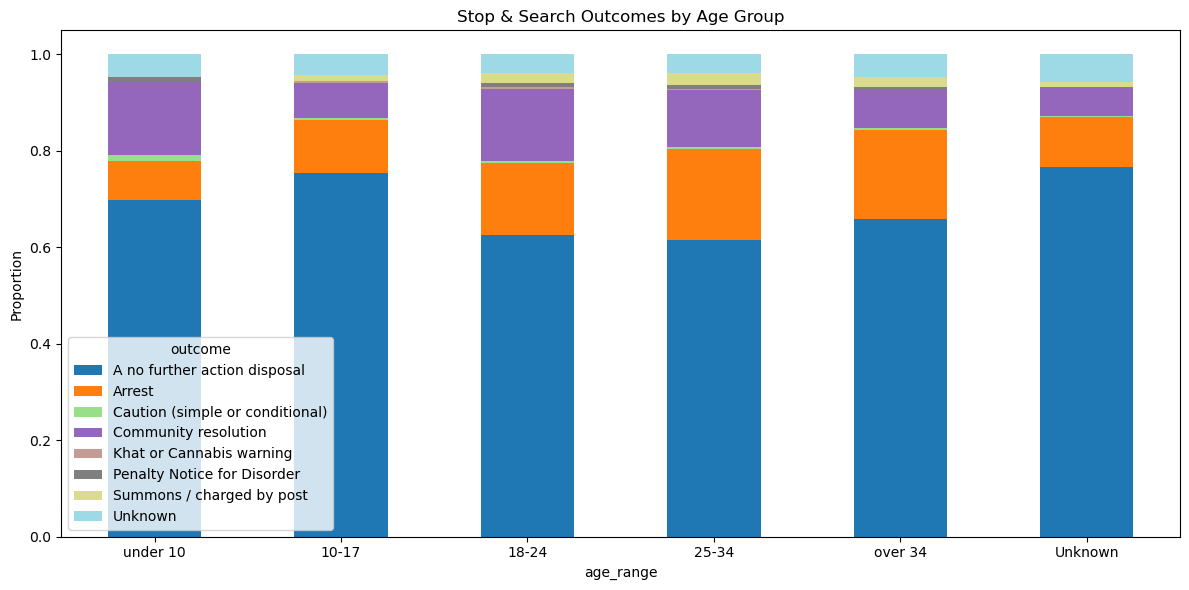

In [78]:
# Define age order
age_order = ["under 10", "10-17", "18-24", "25-34", "over 34", "Unknown"]

# Build table: outcomes by age group
outcomes_by_age = (
    df2.groupby("age_range")["outcome"]
       .value_counts(normalize=True)
       .unstack(fill_value=0)
       .reindex(age_order)  # enforce chronological order
)

# Plot
outcomes_by_age.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="tab20",
    title="Stop & Search Outcomes by Age Group"
)
plt.xticks(rotation=0, ha="center")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()



Text(0.5, 0, 'Age Group')

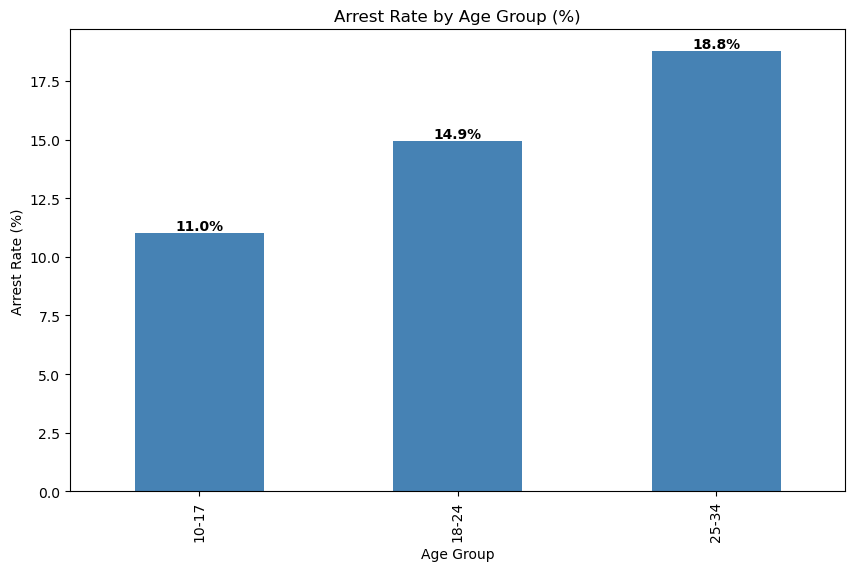

In [79]:
# Arrests by age group
arrest_by_age = (
    df2.groupby("age_range")["outcome"]
    .apply(lambda x: (x == "Arrest").mean() * 100)  # percentage
    .reindex(["Under 10","10-17","18-24","25-34","35-44","45-54","55-64","65+"])  # chronological order
    .dropna()
)

# Plot
ax = arrest_by_age.plot(
    kind="bar", 
    figsize=(10,6), 
    color="steelblue", 
    title="Arrest Rate by Age Group (%)"
)

# Add % labels
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Arrest Rate (%)")
ax.set_xlabel("Age Group")


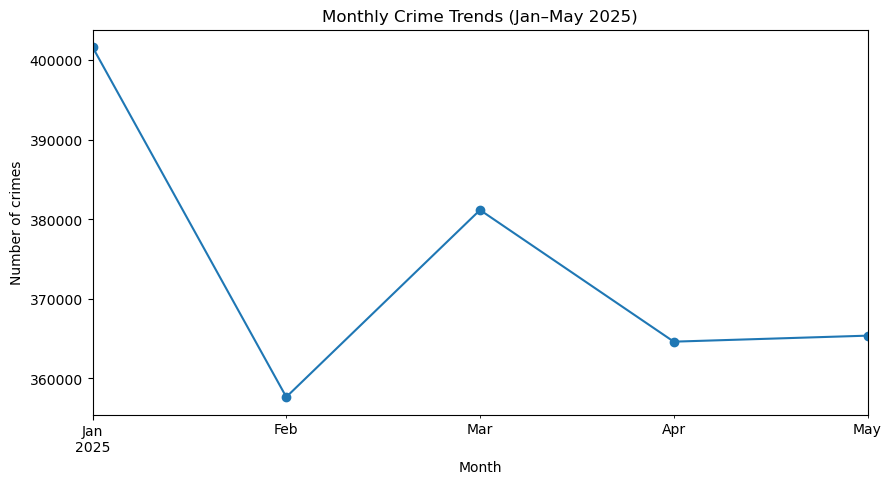

In [80]:
# Monthly crime trends (Outcomes dataset)
monthly_trends = df1.groupby(df1["month"].dt.to_period("M"))["crime_id"].count()

monthly_trends.plot(kind="line", marker="o", figsize=(10,5),
                    title="Monthly Crime Trends (Jan–May 2025)")
plt.ylabel("Number of crimes")
plt.xlabel("Month")
plt.show()


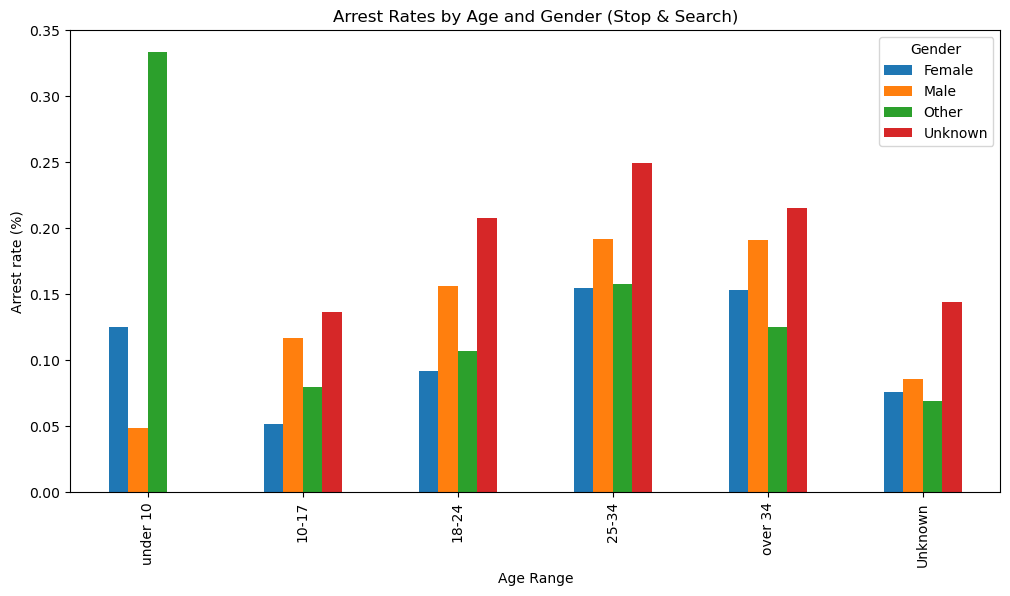

In [81]:
# Define chronological age order
age_order = ["under 10", "10-17", "18-24", "25-34", "over 34", "Unknown"]


# Calculate arrest rates by Age × Gender
age_gender_arrest = (
    df2[df2["outcome"] == "Arrest"]
    .groupby(["age_range", "gender"]).size()
    / df2.groupby(["age_range", "gender"]).size()
).unstack()

# Reorder rows based on age_order
age_gender_arrest = age_gender_arrest.reindex(age_order)

# Plot
age_gender_arrest.plot(kind="bar", figsize=(12,6))
plt.title("Arrest Rates by Age and Gender (Stop & Search)")
plt.ylabel("Arrest rate (%)")
plt.xlabel("Age Range")
plt.legend(title="Gender")
plt.show()



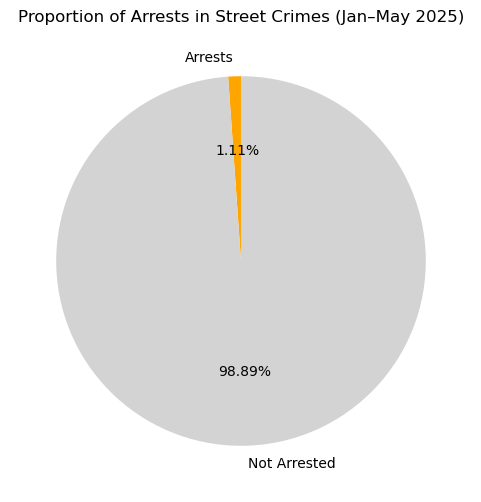

In [82]:
import matplotlib.pyplot as plt

street_crimes = len(df3)
arrests = (df2["outcome"] == "Arrest").sum()

fig, ax = plt.subplots(figsize=(6,6))
ax.pie([arrests, street_crimes - arrests],
       labels=["Arrests","Not Arrested"],
       autopct="%.2f%%", startangle=90, colors=["orange","lightgrey"])
ax.set_title("Proportion of Arrests in Street Crimes (Jan–May 2025)")
plt.show()



In [130]:
import pandas as pd
import re
import folium
from folium.plugins import HeatMap, MarkerCluster

# ---------------------------
# 1) Load and normalise names
# ---------------------------
df = pd.read_csv("stop_search_final.csv")   # <- your file

# normalise col names: lower, underscores
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(r"[^\w]+", "_", regex=True)
)

# helpful debug
print("Columns:", list(df.columns)[:40])

# ---------------------------
# 2) Make sure lat/lon exist
# ---------------------------
# common variants
lat_candidates = ["latitude", "lat"]
lon_candidates = ["longitude", "lon", "lng", "long"]

def pick(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    raise KeyError(f"None of {candidates} found in columns: {cols}")

lat_col = pick(df.columns, lat_candidates)
lon_col = pick(df.columns, lon_candidates)

# keep rows with valid UK bounds
df = df[[lat_col, lon_col] + [c for c in df.columns if c not in [lat_col, lon_col]]].copy()
df = df.dropna(subset=[lat_col, lon_col])
df[lat_col] = df[lat_col].astype(float)
df[lon_col] = df[lon_col].astype(float)
df = df[(df[lat_col].between(49.8, 60.9)) & (df[lon_col].between(-8.5, 2.1))]

# ---------------------------------------
# 3) Build eth_group (if it's not present)
# ---------------------------------------
if "eth_group" not in df.columns:
    # try to find any ethnicity column
    eth_candidates = [
        "eth_group",                 # already-normalised
        "self_defined_ethnicity",
        "self_defined_ethnic_group",
        "officer_defined_ethnicity",
        "officer_defined_ethnic_group",
        "ethnicity",                 # sometimes appears
    ]
    eth_col = None
    for c in eth_candidates:
        if c in df.columns:
            eth_col = c
            break

    def map_eth(x: str) -> str:
        if pd.isna(x):
            return "Unknown"
        s = str(x).lower()
        # map common tokens to high-level 5 groups
        if any(k in s for k in ["white"]):
            return "White"
        if any(k in s for k in ["black", "african", "caribbean"]):
            return "Black"
        if any(k in s for k in ["asian", "bangladeshi", "pakistani", "indian", "chinese"]):
            return "Asian"
        if "mixed" in s:
            return "Mixed"
        if "other" in s:
            return "Other"
        return "Unknown"

    if eth_col is not None:
        df["eth_group"] = df[eth_col].apply(map_eth)
    else:
        df["eth_group"] = "Unknown"

# ---------------------------
# 4) Choose optional fields
# ---------------------------
def first_existing(*names):
    for n in names:
        if n in df.columns:
            return n
    return None

outcome_col = first_existing("outcome", "outcome_linked_to_object_of_search", "result", "disposal")
object_col  = first_existing("object_of_search", "object_search", "purpose", "reason_for_search")

# ---------------------------
# 5) Make the Folium map
# ---------------------------
m = folium.Map(location=[52.9, -1.2], zoom_start=6, tiles="CartoDB positron", control_scale=True)

# Heatmap
heat_fg = folium.FeatureGroup(name="Density heatmap", show=True)
heat_data = df[[lat_col, lon_col]].values.tolist()
HeatMap(heat_data, radius=10, blur=15, max_zoom=10).add_to(heat_fg)
heat_fg.add_to(m)

# Clustered markers
cluster_fg = folium.FeatureGroup(name="Points (clustered)", show=True)
cluster = MarkerCluster().add_to(cluster_fg)

def s(val):  # safe stringify
    return "" if pd.isna(val) else str(val)

for _, r in df.iterrows():
    popup_parts = []
    if outcome_col: popup_parts.append(f"<b>Outcome:</b> {s(r[outcome_col])}")
    if object_col:  popup_parts.append(f"<b>Object of search:</b> {s(r[object_col])}")
    popup_parts.append(f"<b>Ethnicity:</b> {s(r['eth_group'])}")
    popup_html = "<br>".join(popup_parts)

    folium.Marker(
        location=[r[lat_col], r[lon_col]],
        popup=folium.Popup(popup_html, max_width=300),
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(cluster)

cluster_fg.add_to(m)

# Fit to data bounds
sw = [df[lat_col].min(), df[lon_col].min()]
ne = [df[lat_col].max(), df[lon_col].max()]
m.fit_bounds([sw, ne])

folium.LayerControl(collapsed=False).add_to(m)

# Save as index.html (replace your current page)
m.save("index.html")
print("Saved to index.html")


Columns: ['type', 'date', 'part_of_a_policing_operation', 'latitude', 'longitude', 'gender', 'age_range', 'self_defined_ethnicity', 'officer_defined_ethnicity', 'legislation', 'object_of_search', 'outcome', 'outcome_linked_to_object_of_search', 'removal_of_more_than_just_outer_clothing']
Saved to index.html


## **Predictive Processing**

              precision    recall  f1-score   support

           0      0.883     0.627     0.733     40327
           1      0.210     0.545     0.304      7369

    accuracy                          0.614     47696
   macro avg      0.547     0.586     0.518     47696
weighted avg      0.779     0.614     0.667     47696

ROC AUC: 0.625


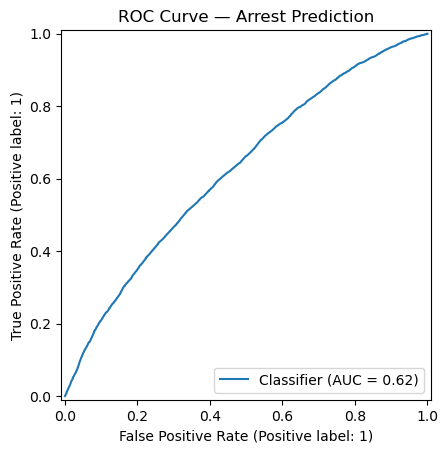

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Target: Arrest vs Not
df2["is_arrest"] = (df2["outcome"] == "Arrest").astype(int)

# Features: demographics + search info
feat_cols = ["age_range", "gender", "eth_group", "object_of_search", "day_of_week"]
X = pd.get_dummies(df2[feat_cols], drop_first=True).astype(int)
y = df2["is_arrest"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Handle imbalance
pos_w = (y_train == 0).sum() / (y_train == 1).sum()

# Model
xgb = XGBClassifier(
    eval_metric="auc",
    scale_pos_weight=pos_w,
    random_state=42
)
xgb.fit(X_train, y_train)

# Predictions
y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=3))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 3))

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve — Arrest Prediction")
plt.show()


In [84]:
from sklearn.utils import resample

# Separate majority and minority classes
df_majority = df2[df2["outcome"] != "Arrest"]
df_minority = df2[df2["outcome"] == "Arrest"]

# Upsample minority
df_minority_upsampled = resample(df_minority,
                                 replace=True,     # sample with replacement
                                 n_samples=len(df_majority), # match majority size
                                 random_state=42)

# Combine back
df_balanced = pd.concat([df_majority, df_minority_upsampled])

print("Before:", df2["outcome"].value_counts(normalize=True))
print("After:", df_balanced["outcome"].value_counts(normalize=True))


Before: outcome
A no further action disposal       0.670772
Arrest                             0.154500
Community resolution               0.099394
Unknown                            0.044237
Summons / charged by post          0.018090
Penalty Notice for Disorder        0.005604
Caution (simple or conditional)    0.004642
Khat or Cannabis warning           0.002761
Name: proportion, dtype: float64
After: outcome
Arrest                             0.500000
A no further action disposal       0.396672
Community resolution               0.058778
Unknown                            0.026160
Summons / charged by post          0.010698
Penalty Notice for Disorder        0.003314
Caution (simple or conditional)    0.002745
Khat or Cannabis warning           0.001633
Name: proportion, dtype: float64
